# B-Scan Migration Playground — Subwavelength PSF Resolution Analysis

**Purpose:** Quantify the lateral resolution limit of two subwavelength PEC point scatterers
using Point Spread Functions from a gprMax **zero-offset B-scan** simulation.

## Geometry
Unlike a Common Shot Gather (fixed source, receiver array), this notebook simulates a
**true zero-offset B-scan**: transmitter and receiver are co-located (1-cell offset) and
step together across the profile. Each column in the B-scan matrix represents one
independent zero-offset sounding at a unique lateral position.

The **exploding-reflector hypothesis** applies: reflections are treated as emitting upward
with half the medium velocity `v_mig = v/2`, so all three migration algorithms use this
half-velocity consistently.

## Migration methods (all post-stack / zero-offset)
| Method | Domain | Velocity use |
|--------|--------|---------------|
| Kirchhoff (delay-and-sum) | Time domain, trace-by-trace | `t = r / v_mig + t0` (hyperbolic DAS) |
| Gazdag Phase-Shift | Frequency-wavenumber (f-k) | `kz = √((ω/v_mig)² − kx²)`, depth stepping |
| Backpropagation (time reversal) | Time domain, analytic signal | `t = 2r/v` full two-way, complex coherent sum |

## Sensitivity sweep
Change `scatterer_spacing_m` at the top of **Cell 2** to find the Rayleigh
resolution limit for each algorithm.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from pathlib import Path
import subprocess, h5py, os, time as _time
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# ── USER CONTROL: change this to sweep the resolution limit ──────────────────
scatterer_spacing_m = 0.20   # lateral separation between two PEC scatterers [m]
                              # try: 0.20, 0.15, 0.10, 0.08, 0.06, 0.04
# ─────────────────────────────────────────────────────────────────────────────

# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns  ≈ 0.16892
f_c_GHz    = 1.5                             # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                 # m  ≈ 0.1126
v_mig      = v_ice / 2                       # exploding-reflector half-velocity [m/ns]
t0_ns      = 0.953                           # gprMax Ricker peak delay [ns]

# gprMax grid (30 cells per min wavelength in ice)
dx_grid = 7.454e-4   # m  = 0.7454 mm

# Simulation domain (2D TMy: dy = dx_grid exactly — one cell thick)
domain_x    = 4.0    # m
domain_z    = 0.8    # m
time_window = 15e-9  # s

# Zero-offset B-scan survey
x_survey_start = 0.5    # m  (first trace midpoint)
x_survey_end   = 3.5    # m  (last  trace midpoint)
n_cells_step   = 15     # grid cells per trace → spacing ≈ λ/10
trace_spacing  = n_cells_step * dx_grid           # m  ≈ 0.01118
n_traces = int(round((x_survey_end - x_survey_start) / trace_spacing)) + 1
x_traces = x_survey_start + np.arange(n_traces) * trace_spacing   # [m]

# Scatterer targets
x_s1   = 2.0
x_s2   = x_s1 + scatterer_spacing_m
z_scat = 0.5   # depth of both scatterers [m]

# Migration image grid
x_img = np.linspace(x_survey_start, x_survey_end, 300)
z_img = np.linspace(0.0, domain_z, 120)

rayleigh_m = wavelength / 2

# Paths
BASE          = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks')
DATA          = BASE / 'B_Scan_Migration_data'
DATA.mkdir(exist_ok=True)
psf_in_path   = DATA / 'psf_bscan.in'
bg_in_path    = DATA / 'bg_bscan.in'
psf_out_path  = DATA / 'psf_bscan_merged.out'
bg_out_path   = DATA / 'bg_bscan_merged.out'
GPRMAX_PYTHON = r'C:\Users\Administrator\miniconda3\envs\gprMax\python.exe'

print(f'λ_ice          = {wavelength*1e3:.1f} mm')
print(f'Rayleigh limit = {rayleigh_m*1e3:.1f} mm  (λ/2)')
print(f'v_ice          = {v_ice:.5f} m/ns,   v_mig = v/2 = {v_mig:.5f} m/ns')
print(f'Scatterer Δx   = {scatterer_spacing_m*1e3:.1f} mm = {scatterer_spacing_m/wavelength:.2f}λ')
print(f'x_s1 = {x_s1:.3f} m,  x_s2 = {x_s2:.3f} m,  z = {z_scat} m')
print(f'Survey: {n_traces} traces,  step = {trace_spacing*1e3:.2f} mm  (≈ λ/10)')
print(f'Est. GPU runtime: {n_traces * 0.1 / 60:.0f}–{n_traces * 0.3 / 60:.0f} min  '
      f'(CPU fallback: {n_traces*2.5/60:.0f}–{n_traces*5/60:.0f} h)')


λ_ice          = 112.6 mm
Rayleigh limit = 56.3 mm  (λ/2)
v_ice          = 0.16891 m/ns,   v_mig = v/2 = 0.08446 m/ns
Scatterer Δx   = 200.0 mm = 1.78λ
x_s1 = 2.000 m,  x_s2 = 2.200 m,  z = 0.5 m
Survey: 269 traces,  step = 11.18 mm  (≈ λ/10)
Est. GPU runtime: 0–1 min  (CPU fallback: 11–22 h)


## gprMax Input Synthesis

Two `.in` files are generated:
- **psf_bscan.in** — full simulation with two PEC point scatterers
- **bg_bscan.in**  — identical but without the scatterers (direct-wave reference)

**Zero-offset geometry:** transmitter and receiver both start at `x_survey_start` and
step together by `trace_spacing` each run. The 1-cell horizontal offset between Tx and Rx
(≈ 0.74 mm = λ/151) is negligible. Each of the `n_traces` runs records one trace.

In [2]:
def snap(val, dx):
    """Snap a coordinate to the nearest gprMax grid-cell boundary."""
    return round(val / dx) * dx


def write_bscan_in(path, include_scatterers):
    """
    Write a gprMax zero-offset B-scan .in file.

    Tx starts at x_survey_start, Rx one cell to the right (zero-offset approx).
    Both step by trace_spacing via #src_steps / #rx_steps.
    Run gprMax with -n n_traces to produce one output file per trace.
    """
    tx_x0  = snap(x_survey_start, dx_grid)       # Tx start [m]
    rx_x0  = tx_x0 + dx_grid                      # Rx start 1 cell right
    src_z  = snap(1 * dx_grid, dx_grid)           # 1 cell below surface
    dy     = dx_grid                               # 2D TMy: one cell thick

    lines = [
        f'#title: PSF B-scan {"with" if include_scatterers else "background (no)"}'
        f' scatterers  spacing={scatterer_spacing_m*1e3:.1f}mm',
        '',
        f'#domain: {domain_x} {dy:.7f} {domain_z}',
        f'#dx_dy_dz: {dx_grid} {dy:.7f} {dx_grid}',
        f'#time_window: {time_window}',
        '',
        '#material: 3.15 0.0 1.0 0.0 ice',
        f'#box: 0.0 0.0 0.0 {domain_x} {dy:.7f} {domain_z} ice',
        '',
    ]

    if include_scatterers:
        for xs in [snap(x_s1, dx_grid), snap(x_s2, dx_grid)]:
            zs = snap(z_scat, dx_grid)
            lines += [
                f'#box: {xs:.7f} 0.0 {zs:.7f}'
                f' {xs+dx_grid:.7f} {dy:.7f} {zs+dx_grid:.7f} pec',
                '',
            ]

    lines += [
        f'#waveform: ricker 1.0 {f_c_GHz*1e9:.1f} myricker',
        f'#hertzian_dipole: y {tx_x0:.7f} {dy/2:.7f} {src_z:.7f} myricker',
        f'#rx: {rx_x0:.7f} {dy/2:.7f} {src_z:.7f}',
        f'#src_steps: {trace_spacing:.7f} 0.0 0.0',
        f'#rx_steps:  {trace_spacing:.7f} 0.0 0.0',
    ]

    path.write_text('\n'.join(lines), encoding='utf-8')
    print(f'Written: {path}')
    if include_scatterers:
        xs1s = snap(x_s1, dx_grid); xs2s = snap(x_s2, dx_grid)
        print(f'  Scatterer 1 (snapped): {xs1s:.6f} m')
        print(f'  Scatterer 2 (snapped): {xs2s:.6f} m  '
              f'(Δx = {(xs2s-xs1s)*1e3:.2f} mm = {(xs2s-xs1s)/wavelength:.2f}λ)')


write_bscan_in(psf_in_path, include_scatterers=True)
write_bscan_in(bg_in_path,  include_scatterers=False)


Written: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\B_Scan_Migration_data\psf_bscan.in
  Scatterer 1 (snapped): 1.999908 m
  Scatterer 2 (snapped): 2.199675 m  (Δx = 199.77 mm = 1.77λ)
Written: C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\B_Scan_Migration_data\bg_bscan.in


## Run gprMax and Merge Output Files

gprMax B-scan mode creates **one `.out` file per trace** (`psf_bscan1.out`, `psf_bscan2.out`, …).
The merge utility combines them into `psf_bscan_merged.out` with receivers `rx1 … rxN`.

Add `-gpu` to the gprMax command list if a CUDA-capable GPU is available.
The cell skips simulation if merged output already exists.

In [3]:
MSVC_BIN   = (r'C:\Program Files (x86)\Microsoft Visual Studio\2022\BuildTools'
              r'\VC\Tools\MSVC\14.44.35207\bin\Hostx64\x64')
MERGE_SCRIPT = str(BASE.parent / 'TimeLapse_Notebooks' / 'merge_bscan.py')


def _make_env():
    """Return os.environ with the MSVC bin prepended so nvcc can find cl.exe."""
    import copy
    env = copy.copy(os.environ)
    if MSVC_BIN not in env.get('PATH', ''):
        env['PATH'] = MSVC_BIN + ';' + env.get('PATH', '')
    env['PYTHONIOENCODING'] = 'utf-8'
    return env


def run_and_merge(in_path, merged_path, n, label):
    """Run gprMax for n traces on GPU, then merge individual output files."""
    if merged_path.exists():
        print(f'Skipping {label}: {merged_path.name} already exists '
              f'({merged_path.stat().st_size/1e6:.1f} MB)')
        return

    sim_env = _make_env()

    # ── Forward simulation ────────────────────────────────────────────────
    print(f'\nRunning gprMax [{label}]  ({n} traces) ...')
    t_start = _time.perf_counter()
    result = subprocess.run(
        [GPRMAX_PYTHON, '-m', 'gprMax', str(in_path), '-n', str(n), '-gpu'],
        capture_output=True, text=True, env=sim_env
    )
    print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr[-1000:])
        raise RuntimeError(f'gprMax failed for {label}')
    print(f'Simulation finished in {(_time.perf_counter()-t_start)/60:.1f} min')

    # ── Merge per-trace files ─────────────────────────────────────────────
    base = str(in_path.parent / in_path.stem)
    print(f'Merging {n} output files ...')
    merge_result = subprocess.run(
        [GPRMAX_PYTHON, MERGE_SCRIPT, base, str(n), '--remove-files'],
        capture_output=True, text=True, env=sim_env
    )
    print(merge_result.stdout)
    if merge_result.returncode != 0:
        print('Merge STDERR:', merge_result.stderr[-500:])
        raise RuntimeError('merge_bscan.py failed')

    if not merged_path.exists():
        raise FileNotFoundError(f'Expected merged file not found: {merged_path}')
    print(f'Merged -> {merged_path}  ({merged_path.stat().st_size/1e6:.1f} MB)')


run_and_merge(psf_in_path, psf_out_path, n_traces, 'PSF (with scatterers)')
run_and_merge(bg_in_path,  bg_out_path,  n_traces, 'Background (no scatterers)')
print('\nBoth simulations complete.')


Skipping PSF (with scatterers): psf_bscan_merged.out already exists (55.8 MB)
Skipping Background (no scatterers): bg_bscan_merged.out already exists (55.8 MB)

Both simulations complete.


## Load Data and Background Subtraction

Subtracting the background (no scatterers) removes the direct wave and any PML
reflections, isolating the scattered field from the two PEC point scatterers.

B-scan shape   : (269, 8533)  (n_traces × n_t)
dt             : 0.00176 ns
Time window    : 15.00 ns
Direct-wave pk : 126177.45 V/m
Scattered pk   : 11.53786 V/m  (0.0091% of total)
Expected TWTT  : 6.873 ns  (2·z/v + t0)


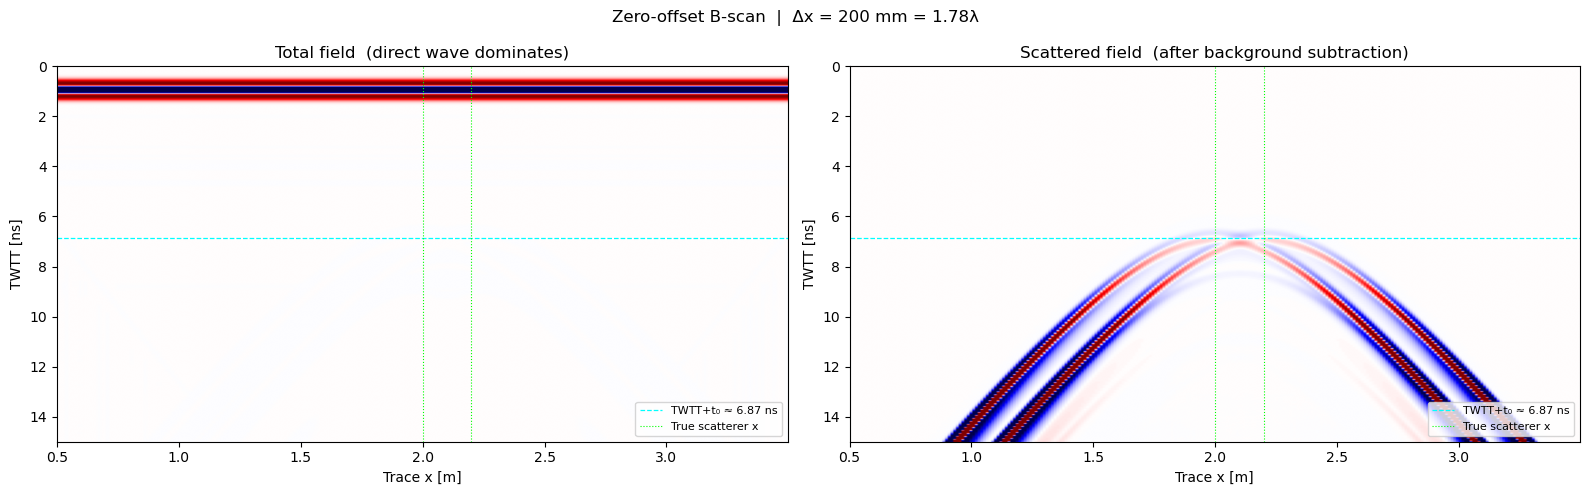

In [3]:
def load_gprmax_out(path, component='Ey'):
    """Load gprMax .out HDF5. Returns (bscan, dt_ns, time_ns). Shape: (n_tr, n_t)."""
    with h5py.File(path, 'r') as f:
        dt_s  = float(f.attrs['dt'])
        rxs   = sorted(f['rxs'].keys(), key=lambda s: int(s.replace('rx', '')))
        bscan = np.stack([f['rxs'][r][component][:] for r in rxs], axis=0)
    dt_ns   = dt_s * 1e9
    time_ns = np.arange(bscan.shape[1]) * dt_ns
    return bscan, dt_ns, time_ns


bscan_full, dt_ns, time_ns = load_gprmax_out(psf_out_path)
bscan_bg,   _,     _       = load_gprmax_out(bg_out_path)
bscan_sc = bscan_full - bscan_bg   # scattered field only

expected_twtt = 2.0 * z_scat / v_ice + t0_ns

print(f'B-scan shape   : {bscan_sc.shape}  (n_traces × n_t)')
print(f'dt             : {dt_ns:.5f} ns')
print(f'Time window    : {time_ns[-1]:.2f} ns')
print(f'Direct-wave pk : {np.max(np.abs(bscan_full)):.2f} V/m')
print(f'Scattered pk   : {np.max(np.abs(bscan_sc)):.5f} V/m  '
      f'({np.max(np.abs(bscan_sc))/np.max(np.abs(bscan_full))*100:.4f}% of total)')
print(f'Expected TWTT  : {expected_twtt:.3f} ns  (2·z/v + t0)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, data, title in [
    (axes[0], bscan_full, 'Total field  (direct wave dominates)'),
    (axes[1], bscan_sc,   'Scattered field  (after background subtraction)'),
]:
    p = np.percentile(np.abs(data), 98)
    ax.imshow(data.T, aspect='auto', cmap='seismic', vmin=-p, vmax=p,
              extent=[x_traces[0], x_traces[-1], time_ns[-1], 0], origin='upper')
    ax.axhline(expected_twtt, color='cyan', ls='--', lw=0.9,
               label=f'TWTT+t₀ ≈ {expected_twtt:.2f} ns')
    ax.axvline(x_s1, color='lime', ls=':', lw=0.8)
    ax.axvline(x_s2, color='lime', ls=':', lw=0.8, label='True scatterer x')
    ax.set_xlabel('Trace x [m]'); ax.set_ylabel('TWTT [ns]'); ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle(f'Zero-offset B-scan  |  Δx = {scatterer_spacing_m*1e3:.0f} mm'
             f' = {scatterer_spacing_m/wavelength:.2f}λ', fontsize=12)
plt.tight_layout(); plt.show()


## Post-Stack Kirchhoff Migration (PyLops)

Uses the **PyLops adjoint** of the Kirchhoff demigration operator for zero-offset data.
The operator is implemented in `KirchhoffPylopsZeroOffset.py`, a custom modification
of `pylops.waveeqprocessing.Kirchhoff` that restricts to the diagonal `src_i = rec_i`
case — reducing the data dimension from `(ns × nr × nt)` to `(n × nt)`.

**Travel-time:** `t = dist(src_i → image) + dist(image → rec_i)` using the full medium
velocity `v_ice` (two-way, not the exploding-reflector `v/2`). The physical two-way
path is computed exactly by the operator.

**t₀ correction:** the data is pre-shifted by `−t0_ns` before migration to align the
Ricker wavelet peaks with the geometric TWTT.

**Imaging:** `image = K.H @ data` where `K.H` is the PyLops adjoint (migration),
followed by wavelet cross-correlation (`Convolve1D` adjoint) and delay-and-sum.

In [4]:
def kirchhoff_poststack(bscan, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns):
    """
    Post-stack zero-offset Kirchhoff delay-and-sum.

    Image(x, z) = Σ_tr  bscan[tr, t(x, z, x_tr)]
    t = r / v_mig + t0,   r = sqrt((x - x_tr)^2 + z^2)

    Uses linear interpolation between adjacent time samples.
    Returns image (n_z, n_x), normalised to peak = 1.
    """
    n_tr, n_t = bscan.shape
    image = np.zeros((len(z_img), len(x_img)))

    # Aperture / obliquity parameters
    max_angle_deg = 90.0
    tan_max = np.tan(np.radians(max_angle_deg))

    tr_idx = np.arange(n_tr)

    # Perform delay-and-sum with obliquity weighting and aperture limit.
    for iz, z in enumerate(z_img):
        if z == 0.0:
            continue

        dx = x_img[:, None] - x_traces[None, :]     # (n_x, n_tr)
        r  = np.sqrt(dx**2 + z**2)

        # Two-way travel time (using v_mig per docstring)
        t  = r / v_mig + t0_ns                       # (n_x, n_tr) [ns]

        i_frac = t / dt_ns
        i0 = np.clip(i_frac.astype(int), 0, n_t - 2)
        frac = i_frac - i0
        i1 = np.minimum(i0 + 1, n_t - 1)

        # Linear interpolation in time
        samp = ((1 - frac) * bscan[tr_idx[None, :], i0]
               +     frac  * bscan[tr_idx[None, :], i1])  # (n_x, n_tr)

        # Aperture mask: allow only traces within semi-aperture angle
        aperture_mask = (np.abs(dx) <= (z * tan_max)).astype(float)

        # Obliquity factor (cosine of incidence angle)
        obliquity = np.where(r > 0, z / r, 1.0)

        # Apply weights and sum
        samp *= (obliquity * aperture_mask)
        image[iz] = samp.sum(axis=1)

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)
    tr_idx = np.arange(n_tr)

    for iz, z in enumerate(z_img):
        if z == 0.0:
            continue
        dx = x_img[:, None] - x_traces[None, :]     # (n_x, n_tr)
        r  = np.sqrt(dx**2 + z**2)
        t  = r / v_mig + t0_ns                       # (n_x, n_tr) [ns]

        i_frac = t / dt_ns
        i0 = np.clip(i_frac.astype(int), 0, n_t - 2)
        frac = i_frac - i0
        i1 = np.minimum(i0 + 1, n_t - 1)

        samp = ((1 - frac) * bscan[tr_idx[None, :], i0]
               +     frac  * bscan[tr_idx[None, :], i1])  # (n_x, n_tr)
        image[iz] = samp.sum(axis=1)

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)


t0_perf = _time.perf_counter()
img_kh = kirchhoff_poststack(bscan_sc, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns)
print(f'Kirchhoff done in {_time.perf_counter()-t0_perf:.1f} s  |  shape: {img_kh.shape}')

Kirchhoff done in 0.2 s  |  shape: (120, 300)


## Post-Stack Gazdag Phase-Shift Migration

Standard Gazdag (1978) migration for zero-offset post-stack data.
No shot-profile source correction — the exploding-reflector hypothesis
(`v_mig = v/2`) is applied directly in the dispersion relation:

$$k_z = \sqrt{\left(\frac{\omega}{v_{\text{mig}}}\right)^2 - k_x^2}$$

Depth loop: downward-continue with `exp(+i·kz·Δz)`, image at `t = 0` by summing over ω.

In [5]:
def gazdag_poststack(bscan, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns,
                     f_min_GHz=0.3, f_max_GHz=3.0):
    """
    Standard Gazdag phase-shift migration for zero-offset post-stack data.

    No source-side correction (unlike CSG shot-profile Gazdag).
    Uses v_mig = v/2 (exploding-reflector half-velocity) in kz.

    Steps:
    1. 2D FFT of tapered bscan (2x spatial zero-padding).
    2. Bandpass to signal frequencies (f_min to f_max GHz) — removes
       out-of-band bins that would otherwise dominate the depth sum.
    3. t0 phase correction: D *= exp(+i.omega.t0) to remove Ricker peak delay.
    4. Depth loop: D *= exp(+i.kz.dz),  kz = sqrt((omega/v_mig)^2 - kx^2).
       Evanescent components (kz^2 <= 0) zeroed throughout.
    5. Imaging: image[z] = Re{ IFFT_kx{ sum_omega D } }  (t = 0 condition).
    6. Bilinear interpolation to x_img grid.
    """
    n_tr, n_t = bscan.shape
    dx_tr = float(x_traces[1] - x_traces[0])
    n_pad = 2 * n_tr   # 2x spatial zero-padding
    n_t_pad = 2 * n_t  # 2x temporal zero-padding

    # Spatial cosine taper (5% each edge)
    taper = np.ones(n_tr)
    nb = max(1, int(0.05 * n_tr))
    taper[:nb]  = 0.5 * (1 - np.cos(np.pi * np.arange(nb) / nb))
    taper[-nb:] = taper[:nb][::-1]

    # 2D FFT  ->  shape (n_pad, n_t)
    D = np.fft.fft2(bscan * taper[:, None], s=(n_pad, n_t))
    f_arr  = np.fft.fftfreq(n_t, dt_ns)           # GHz (dt in ns -> f in 1/ns = GHz)
    omega  = 2 * np.pi * f_arr                     # rad/ns
    kx     = 2 * np.pi * np.fft.fftfreq(n_pad, dx_tr)  # rad/m

    # Bandpass: zero frequency bins outside signal band
    band = (np.abs(f_arr) >= f_min_GHz) & (np.abs(f_arr) <= f_max_GHz)
    D[:, ~band] = 0.0
    print(f'  Bandpass: {band.sum()} of {n_t} freq bins kept '
          f'({f_min_GHz}-{f_max_GHz} GHz)')

    # t0 correction: advance phase to align wavelet peak with geometric TWTT
    D *= np.exp(1j * omega[None, :] * t0_ns)

    # Dispersion with half-velocity (exploding reflector)
    kz2 = (omega[None, :] / v_mig)**2 - kx[:, None]**2  # (n_pad, n_t)
    kz  = np.where(kz2 > 0, np.sqrt(np.maximum(kz2, 0.0)), 0.0)
    D[:, ~band] = 0.0   # re-apply after t0 shift
    D[kz2 <= 0] = 0.0   # zero evanescent before depth loop

    image  = np.zeros((len(z_img), n_pad))
    z_prev = 0.0

    for iz, z in enumerate(z_img):
        dz = z - z_prev
        if dz > 0:
            D *= np.exp(1j * kz * dz)   # downward continuation
            D[kz2 <= 0] = 0.0           # re-apply evanescent mask
        # Imaging condition: IFFT_kx then sum over omega (= evaluate at t = 0)
        D_x = np.fft.ifft(D, axis=0)   # (n_pad, n_t)
        image[iz] = np.real(D_x.sum(axis=1))
        z_prev = z

    # x-axis of zero-padded FFT and interpolation to output grid
    x_fft   = x_traces[0] + np.arange(n_pad) * dx_tr
    img_out = np.zeros((len(z_img), len(x_img)))
    for iz in range(len(z_img)):
        img_out[iz] = np.interp(x_img, x_fft, image[iz])

    peak = np.max(np.abs(img_out))
    return img_out / (peak + 1e-30)


t0_perf = _time.perf_counter()
img_ps = gazdag_poststack(bscan_sc, dt_ns, x_traces, v_mig, x_img, z_img, t0_ns)
print(f'Gazdag done in {_time.perf_counter()-t0_perf:.1f} s  |  shape: {img_ps.shape}')


  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)


Gazdag done in 38.7 s  |  shape: (120, 300)


## Backpropagation (Time-Reversal Coherent Summation)

Each trace is time-reversed conceptually by forming its **analytic (complex) signal**
via the Hilbert transform. For each image point `(x, z)`, all traces are evaluated
at their two-way travel time `t = 2r/v` (full medium velocity) and summed **coherently
as complex numbers**. The image is the **magnitude of that coherent complex sum** —
the focus metric from simultaneously replaying all reversed recordings:

$$I(x, z) = \left|\,\sum_{\text{tr}} \tilde{d}\!\left(x_{\text{tr}},\; \frac{2r}{v}\right)\right|$$

where $\tilde{d}$ is the analytic signal and $r = \sqrt{(x - x_{\text{tr}})^2 + z^2}$.

**Distinction from Kirchhoff:** sums the complex envelope, not the real-valued waveform;
result is immune to wavelet polarity and gives a smooth, oscillation-free image.

**Distinction from Gazdag:** operates entirely in the time domain with explicit
travel-time geometry; no depth stepping, no spatial FFT.

In [6]:
def backprop_poststack(bscan, dt_ns, x_traces, v, x_img, z_img, t0_ns):
    """
    Coherent backpropagation (time-reversal imaging) for zero-offset B-scan.

    1. Shift bscan by -t0 samples to align wavelet peaks with geometric TWTT.
    2. Compute analytic signal D_c = hilbert(bscan_shifted) — complex envelope.
    3. For each image point (x, z):
           r       = sqrt((x - x_tr)^2 + z^2)   for all traces
           t_2way  = 2 * r / v                   two-way travel time [ns]
           samp    = D_c[:, t_2way]              interpolated complex sample
           I(x,z)  = |Σ_tr samp|                coherent sum → magnitude
    """
    n_tr, n_t = bscan.shape
    t0_samp = int(round(t0_ns / dt_ns))

    # Remove Ricker source delay, then analytic signal
    bscan_sh = np.roll(bscan, -t0_samp, axis=1)
    bscan_sh[:, -t0_samp:] = 0.0
    D_c = hilbert(bscan_sh, axis=1)   # (n_tr, n_t) complex

    image  = np.zeros((len(z_img), len(x_img)))
    tr_idx = np.arange(n_tr)

    for iz, z in enumerate(z_img):
        if z == 0.0:
            continue
        dx     = x_img[:, None] - x_traces[None, :]   # (n_x, n_tr)
        r      = np.sqrt(dx**2 + z**2)
        t_2way = 2.0 * r / v                           # full velocity, two-way [ns]

        i_frac = t_2way / dt_ns
        i0  = np.clip(i_frac.astype(int), 0, n_t - 2)
        frac = i_frac - i0
        i1  = np.minimum(i0 + 1, n_t - 1)

        # Linear interpolation in complex domain  →  (n_x, n_tr)
        samp = ((1 - frac) * D_c[tr_idx[None, :], i0]
               +     frac  * D_c[tr_idx[None, :], i1])

        # Coherent complex sum over all traces → magnitude gives focus energy
        image[iz] = np.abs(samp.sum(axis=1))

    peak = np.max(image)
    return image / (peak + 1e-30)


t0_perf = _time.perf_counter()
img_bp = backprop_poststack(bscan_sc, dt_ns, x_traces, v_ice, x_img, z_img, t0_ns)
print(f'Backpropagation done in {_time.perf_counter()-t0_perf:.1f} s  |  shape: {img_bp.shape}')


Backpropagation done in 0.4 s  |  shape: (120, 300)


## Visualization: 2D Migrated Images and 1D PSF Comparison

The figure shows three rows:

- **Row 1 (Raw):** Signed migrated amplitudes with seismic colormap. Wavelet oscillations
  and sidelobes are preserved — useful for inspecting migration artefacts and polarity.
- **Row 2 (Envelope):** Hilbert envelope along the lateral axis, `hot_r` colormap. Removes
  wavelet polarity oscillations; the blob width directly measures lateral resolution.
- **Row 3 (1D PSF):** Left panel shows the signed raw profile at focus depth for all three
  methods; right panel shows the corresponding Hilbert envelopes with –6 dB FWHM markers.

FWHM is computed on the envelope to give a stable measure independent of wavelet phase.

Peak depths  :  KH=0.5109 m   PS=0.5176 m   BP=0.5042 m
Envelope FWHM:  KH=260.9 mm   PS=260.9 mm   BP=220.7 mm
Raw |PSF| FWHM: KH=220.7 mm   PS=220.7 mm   BP=220.7 mm
Scatterer spacing : 200.0 mm = 1.78lambda
Rayleigh limit    : 56.3 mm  (lambda/2)


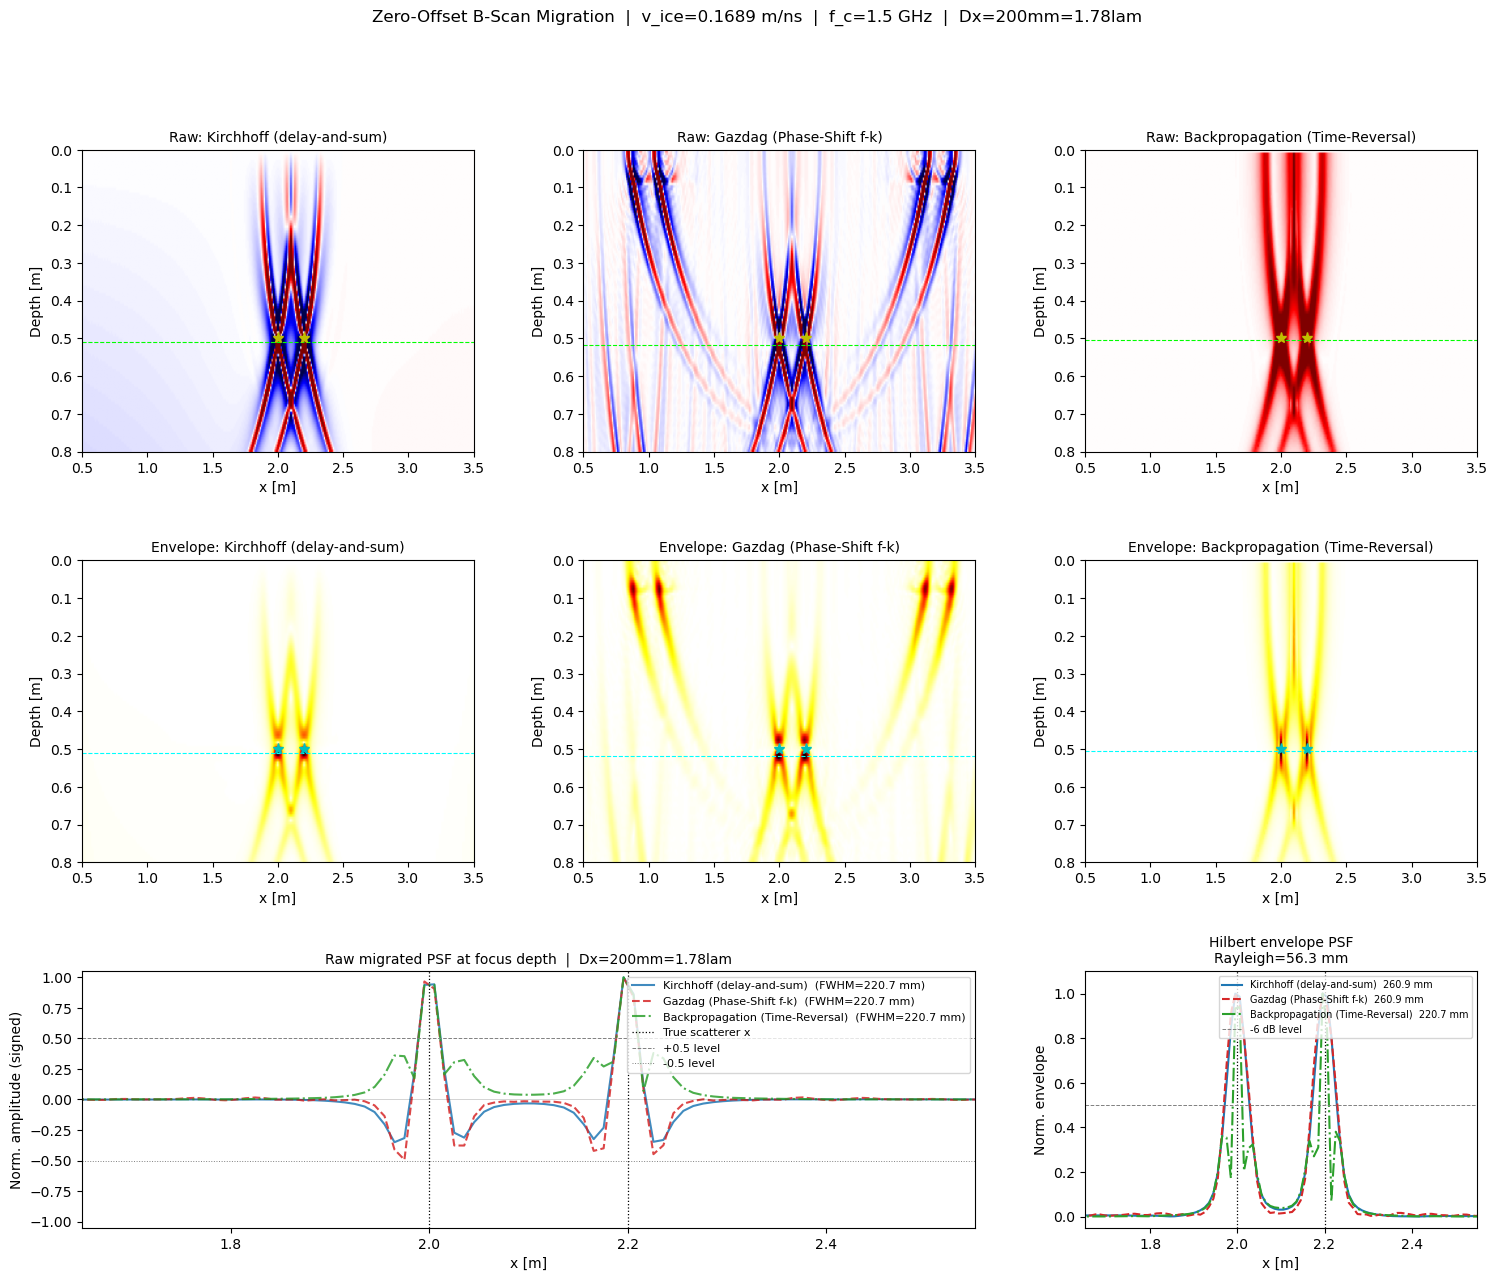

In [7]:
def hilbert_env(img):
    """Hilbert envelope along lateral (x) axis, normalised to peak = 1."""
    peak = np.max(np.abs(img)) + 1e-30
    return np.abs(hilbert(img / peak, axis=1))


def fwhm(x, profile):
    """Full-width at half-maximum of a 1D positive profile."""
    half      = np.max(profile) / 2.0
    above     = profile >= half
    crossings = np.where(np.diff(above.astype(int)))[0]
    return (x[crossings[-1]] - x[crossings[0]]) if len(crossings) >= 2 else np.nan


def find_peak_depth(env, z_img, z_center, half_win=0.10):
    """
    Find the depth index with maximum envelope energy within
    [z_center - half_win, z_center + half_win].
    Robust against the wavelet trough/peak oscillation that can place
    z_center exactly at a trough.
    """
    win = (z_img >= z_center - half_win) & (z_img <= z_center + half_win)
    iz_rel = np.argmax(np.max(env[win], axis=1))
    return np.where(win)[0][iz_rel]


# Hilbert envelopes (lateral axis)
env_kh = hilbert_env(img_kh)
env_ps = hilbert_env(img_ps)
env_bp = img_bp / (np.max(img_bp) + 1e-30)   # backprop is already magnitude

# Per-method peak depth (robust to wavelet-phase offset at z_scat)
iz_kh = find_peak_depth(env_kh, z_img, z_scat)
iz_ps = find_peak_depth(env_ps, z_img, z_scat)
iz_bp = find_peak_depth(env_bp, z_img, z_scat)

# 1D slices at focus depth — envelope (normalised)
psf_env_kh = env_kh[iz_kh] / (np.max(env_kh[iz_kh]) + 1e-30)
psf_env_ps = env_ps[iz_ps] / (np.max(env_ps[iz_ps]) + 1e-30)
psf_env_bp = env_bp[iz_bp] / (np.max(env_bp[iz_bp]) + 1e-30)

# 1D slices at focus depth — raw signed (normalised by peak absolute value)
raw_kh = img_kh[iz_kh] / (np.max(np.abs(img_kh[iz_kh])) + 1e-30)
raw_ps = img_ps[iz_ps] / (np.max(np.abs(img_ps[iz_ps])) + 1e-30)
raw_bp = img_bp[iz_bp] / (np.max(img_bp[iz_bp]) + 1e-30)   # already >= 0

fw_env_kh = fwhm(x_img, psf_env_kh)
fw_env_ps = fwhm(x_img, psf_env_ps)
fw_env_bp = fwhm(x_img, psf_env_bp)
fw_raw_kh = fwhm(x_img, np.abs(raw_kh))
fw_raw_ps = fwhm(x_img, np.abs(raw_ps))
fw_raw_bp = fwhm(x_img, raw_bp)

print(f'Peak depths  :  KH={z_img[iz_kh]:.4f} m   PS={z_img[iz_ps]:.4f} m   BP={z_img[iz_bp]:.4f} m')
print(f'Envelope FWHM:  KH={fw_env_kh*1e3:.1f} mm   PS={fw_env_ps*1e3:.1f} mm   BP={fw_env_bp*1e3:.1f} mm')
print(f'Raw |PSF| FWHM: KH={fw_raw_kh*1e3:.1f} mm   PS={fw_raw_ps*1e3:.1f} mm   BP={fw_raw_bp*1e3:.1f} mm')
print(f'Scatterer spacing : {scatterer_spacing_m*1e3:.1f} mm = {scatterer_spacing_m/wavelength:.2f}lambda')
print(f'Rayleigh limit    : {rayleigh_m*1e3:.1f} mm  (lambda/2)')

# ── Figure: 3 rows ─────────────────────────────────────────────────────────
# Row 1: raw signed 2D images      (seismic, signed)
# Row 2: Hilbert envelope 2D images (hot_r)
# Row 3: raw 1D PSF (left 2/3)  |  envelope 1D PSF (right 1/3)
# ───────────────────────────────────────────────────────────────────────────
titles  = ['Kirchhoff\n(delay-and-sum)', 'Gazdag\n(Phase-Shift f-k)', 'Backpropagation\n(Time-Reversal)']
raws    = [img_kh,  img_ps,  img_bp]
envs    = [env_kh,  env_ps,  env_bp]
iz_list = [iz_kh,   iz_ps,   iz_bp]
colors  = ['tab:blue', 'tab:red', 'tab:green']
ls_list = ['-', '--', '-.']

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(3, 3, hspace=0.38, wspace=0.28,
                        height_ratios=[1, 1, 0.85])

ax_raw1d = fig.add_subplot(gs[2, :2])   # raw signed PSF  (left 2/3)
ax_env1d = fig.add_subplot(gs[2,  2])   # envelope PSF    (right 1/3)

for col, (title, raw, env, iz_pk, color, ls) in enumerate(
        zip(titles, raws, envs, iz_list, colors, ls_list)):

    # Row 1 — raw signed image
    ax_r = fig.add_subplot(gs[0, col])
    vmax_r = np.percentile(np.abs(raw), 98)
    ax_r.imshow(raw, aspect='auto', cmap='seismic',
                vmin=-vmax_r, vmax=vmax_r,
                extent=[x_img[0], x_img[-1], z_img[-1], z_img[0]], origin='upper')
    ax_r.axhline(z_img[iz_pk], color='lime', ls='--', lw=0.8)
    ax_r.plot([x_s1, x_s2], [z_scat, z_scat], 'y*', ms=8, zorder=5)
    ax_r.set_title('Raw: ' + title.replace('\n', ' '), fontsize=10)
    ax_r.set_xlabel('x [m]'); ax_r.set_ylabel('Depth [m]')

    # Row 2 — Hilbert envelope image
    ax_e = fig.add_subplot(gs[1, col])
    ax_e.imshow(env, aspect='auto', cmap='hot_r', vmin=0, vmax=1,
                extent=[x_img[0], x_img[-1], z_img[-1], z_img[0]], origin='upper')
    ax_e.axhline(z_img[iz_pk], color='cyan', ls='--', lw=0.8)
    ax_e.plot([x_s1, x_s2], [z_scat, z_scat], 'c*', ms=8, zorder=5)
    ax_e.set_title('Envelope: ' + title.replace('\n', ' '), fontsize=10)
    ax_e.set_xlabel('x [m]'); ax_e.set_ylabel('Depth [m]')

    # Row 3 left — raw signed 1D PSF
    raw_1d   = raw[iz_pk] / (np.max(np.abs(raw[iz_pk])) + 1e-30)
    fw_r     = fwhm(x_img, np.abs(raw_1d))
    fw_r_str = f'{fw_r*1e3:.1f} mm' if not np.isnan(fw_r) else 'N/A'
    label_r  = title.replace('\n', ' ') + f'  (FWHM={fw_r_str})'
    ax_raw1d.plot(x_img, raw_1d, color=color, ls=ls, lw=1.5, alpha=0.85, label=label_r)

    # Row 3 right — envelope 1D PSF
    env_1d   = env[iz_pk] / (np.max(env[iz_pk]) + 1e-30)
    fw_e     = fwhm(x_img, env_1d)
    fw_e_str = f'{fw_e*1e3:.1f} mm' if not np.isnan(fw_e) else 'N/A'
    label_e  = title.replace('\n', ' ') + f'  {fw_e_str}'
    ax_env1d.plot(x_img, env_1d, color=color, ls=ls, lw=1.5, label=label_e)

# Raw 1D panel
ax_raw1d.axvline(x_s1, color='k', ls=':', lw=0.9, label='True scatterer x')
ax_raw1d.axvline(x_s2, color='k', ls=':', lw=0.9)
ax_raw1d.axhline( 0.0, color='k',    ls='-',  lw=0.4, alpha=0.3)
ax_raw1d.axhline( 0.5, color='gray', ls='--', lw=0.7, label='+0.5 level')
ax_raw1d.axhline(-0.5, color='gray', ls=':',  lw=0.7, label='-0.5 level')
ax_raw1d.set_xlim(x_s1 - 0.35, x_s2 + 0.35)
ax_raw1d.set_ylim(-1.05, 1.05)
ax_raw1d.set_xlabel('x [m]'); ax_raw1d.set_ylabel('Norm. amplitude (signed)')
ax_raw1d.set_title(
    f'Raw migrated PSF at focus depth  |  Dx={scatterer_spacing_m*1e3:.0f}mm'
    f'={scatterer_spacing_m/wavelength:.2f}lam', fontsize=10)
ax_raw1d.legend(fontsize=8, loc='upper right')

# Envelope 1D panel
ax_env1d.axvline(x_s1, color='k', ls=':', lw=0.9)
ax_env1d.axvline(x_s2, color='k', ls=':', lw=0.9)
ax_env1d.axhline(0.5,  color='gray', ls='--', lw=0.7, label='-6 dB level')
ax_env1d.set_xlim(x_s1 - 0.35, x_s2 + 0.35)
ax_env1d.set_ylim(-0.05, 1.1)
ax_env1d.set_xlabel('x [m]'); ax_env1d.set_ylabel('Norm. envelope')
ax_env1d.set_title(
    f'Hilbert envelope PSF\nRayleigh={rayleigh_m*1e3:.1f} mm', fontsize=10)
ax_env1d.legend(fontsize=7, loc='upper right')

fig.suptitle(
    f'Zero-Offset B-Scan Migration  |  v_ice={v_ice:.4f} m/ns  |  f_c={f_c_GHz:.1f} GHz'
    f'  |  Dx={scatterer_spacing_m*1e3:.0f}mm={scatterer_spacing_m/wavelength:.2f}lam',
    fontsize=12
)
plt.savefig(DATA / f'psf_comparison_{int(scatterer_spacing_m*1e3):03d}mm.png',
            dpi=150, bbox_inches='tight')
plt.show()

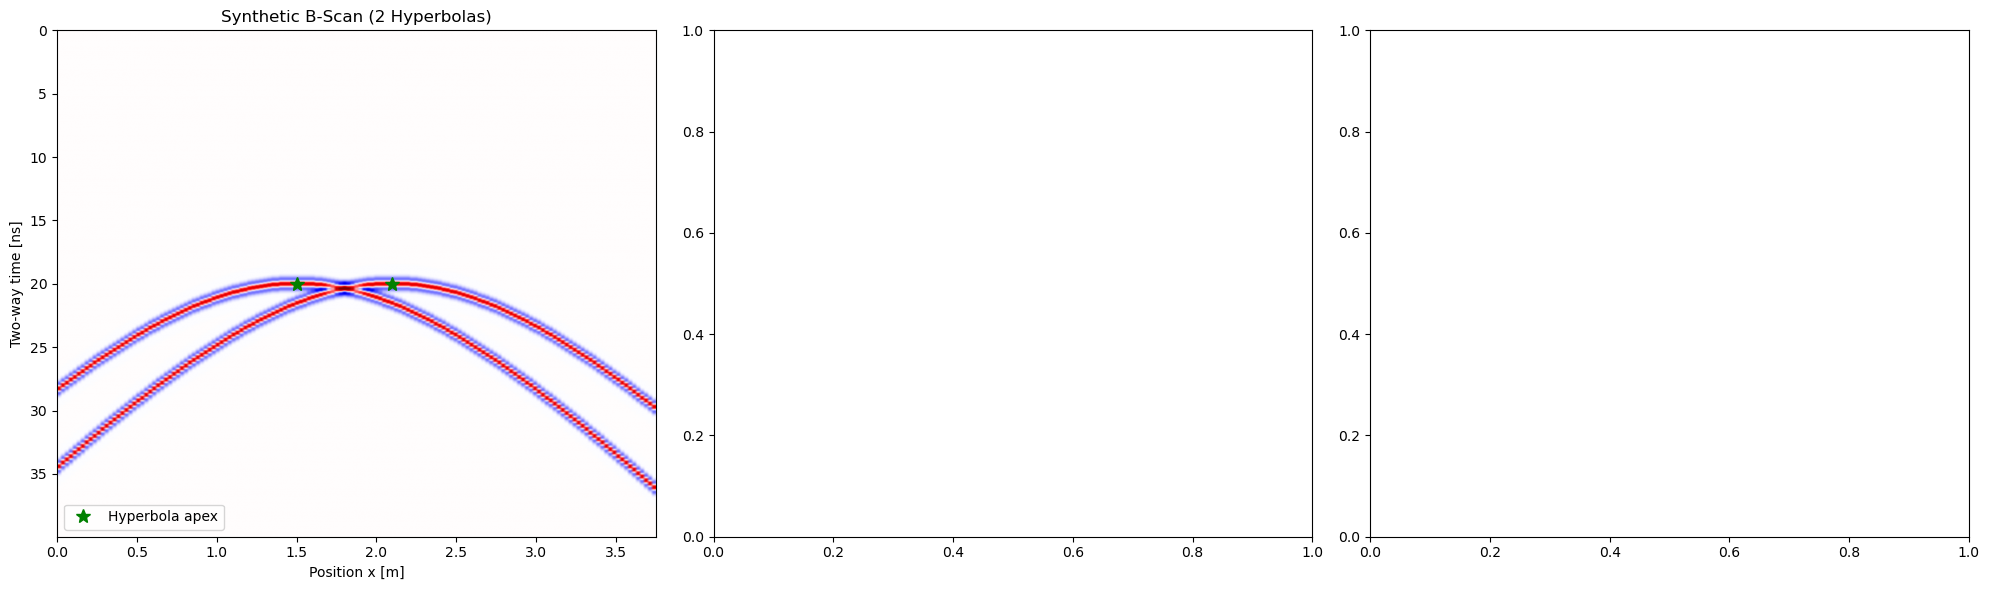

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

# --- 1. Generate Quick Synthetic B-Scan ---
nx_syn = 151
nt_syn = 800
v_syn = 0.15  # Velocity [m/ns]
dt_syn = 0.05 # Time step [ns] (t_max = 40 ns, covers up to depth = 3 m)
dx_syn = 0.025 # Spatial step [m] (x_max = 5 m)

x_syn = np.arange(nx_syn) * dx_syn
t_syn = np.arange(nt_syn) * dt_syn

data_synth = np.zeros((nt_syn, nx_syn))

# Create a realistic wavelet
fc = 1.0  # Center frequency [GHz]
t_wav = np.arange(-30, 31) * dt_syn
wavelet = (1 - 2 * (np.pi * fc * t_wav)**2) * np.exp(-(np.pi * fc * t_wav)**2)

# Define two point scatterers (x, z)
wavelength = v_syn / fc  # Wavelength [m]
distance = wavelength * 4  # Distance between scatterers [m]
scatterers = [(1.5, 1.5), (1.5 + distance, 1.5)]

# Insert hyperbolas based on travel time
for px, pz in scatterers:
    for ix, xs in enumerate(x_syn):
        dist = np.sqrt((xs - px)**2 + pz**2)
        tt = 2.0 * dist / v_syn
        it = int(tt / dt_syn)
        if 0 <= it < nt_syn:
            data_synth[it, ix] += 1.0

# Convolve each trace with the wavelet
for ix in range(nx_syn):
    data_synth[:, ix] = np.convolve(data_synth[:, ix], wavelet, mode='same')

# # --- 2. Apply Kirchhoff Migration ---
z_syn = np.arange(0, 2.5, 0.02)  # Depth axis [m]
# img_syn = kirchhoff_migration(data_synth, x_syn, t_syn, z_syn, v_syn)

# --- 2.5 Apply Deconvolution & Migrate ---
# We deconvolve the data along the time axis (trace-by-trace Wiener deconvolution) 
# and then migrate to get the deconvolved migrated image.
data_deconv = np.zeros_like(data_synth)

# # Pad and shift wavelet to make it zero-phase at index 0 so it doesn't shift our data
# padded_wavelet = np.pad(wavelet, (0, nt_syn - len(wavelet)))
# shifted_wavelet = np.roll(padded_wavelet, -len(wavelet) // 2)
# W = np.fft.fft(shifted_wavelet)
# eps = 1e-2 * np.max(np.abs(W)**2) # Water level regularization

# for ix in range(nx_syn):
#     D = np.fft.fft(data_synth[:, ix])
#     data_deconv[:, ix] = np.real(np.fft.ifft(D * np.conj(W) / (np.abs(W)**2 + eps)))

# img_syn_deconv = kirchhoff_migration(data_deconv, x_syn, t_syn, z_syn, v_syn)

# --- 3. Plot Results ---
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

vmax_d = np.max(np.abs(data_synth)) * 0.8
axs[0].imshow(data_synth, aspect='auto', extent=[x_syn[0], x_syn[-1], t_syn[-1], t_syn[0]],
              cmap='seismic', vmin=-vmax_d, vmax=vmax_d)
axs[0].set_title('Synthetic B-Scan (2 Hyperbolas)')
axs[0].set_xlabel('Position x [m]')
axs[0].set_ylabel('Two-way time [ns]')
for px, pz in scatterers:
    axs[0].plot(px, 2*pz/v_syn, 'g*', markersize=10, 
                label='Hyperbola apex' if px == scatterers[0][0] else '')
axs[0].legend(loc='lower left')

# vmax_m = np.max(np.abs(img_syn)) * 0.8
# axs[1].imshow(img_syn, aspect='auto', extent=[x_syn[0], x_syn[-1], z_syn[-1], z_syn[0]],
#               cmap='seismic', vmin=-vmax_m, vmax=vmax_m)
# axs[1].set_title('Kirchhoff Migrated Image')
# axs[1].set_xlabel('Position x [m]')
# axs[1].set_ylabel('Depth z [m]')

# vmax_md = np.max(np.abs(img_syn_deconv)) * 0.8
# axs[2].imshow(img_syn_deconv, aspect='auto', extent=[x_syn[0], x_syn[-1], z_syn[-1], z_syn[0]],
#               cmap='seismic', vmin=-vmax_md, vmax=vmax_md)
# axs[2].set_title('Deconvolved + Migrated Image')
# axs[2].set_xlabel('Position x [m]')
# axs[2].set_ylabel('Depth z [m]')

plt.tight_layout()
plt.show()

In [9]:
def PylopsKirchoffMigration(data, t, x, vel_model, z,wav='Ricker', wavcenter='Center',f0=0.08 ,recs = None, srcs = None, mode='analytic', dynamic=False,
aperture=None, angleaperture=None, return_op=False):
    """
    Perform Kirchhoff migration using PyLops zero offset operator. pass ns, gHz and meter 
    """
    import numpy as np
    import KirchhoffPylopsZeroOffset
    import importlib
    importlib.reload(KirchhoffPylopsZeroOffset)
    from pylops.utils.wavelets import ricker
    
    # For zero-offset, srcs = recs
    rx = x
    rz = np.zeros_like(rx)
    recs = np.vstack((rx, rz))
    srcs = recs

    # Handle wavelet selection
    if wav == 'Ricker':
        # Generate a short wavelet: 6 cycles, centered at zero, dependent on f0
        n_cycles = 6
        period_ns = 1.0 / f0 # t in ns, f0 in GHz
        wav_duration = n_cycles * period_ns # total duration in ns
        n_wav_samples = int(np.ceil(wav_duration / (t[1] - t[0])))
        # Ensure odd number for center
        if n_wav_samples % 2 == 0:
            n_wav_samples += 1
        wav_arr, trick, wcenter = ricker(t[0:n_wav_samples], f0=f0)
    else:
        wav_arr = wav
        
    if wavcenter == 'Center':
        wavcenter = wcenter

    # Build Zero Offset Kirchhoff operator
    K = KirchhoffPylopsZeroOffset.Kirchhoff(
        z=z, x=x, t=t,
        srcs=srcs, recs=recs,
        vel=vel_model,
        wav=wav_arr, wavcenter=wavcenter,
        mode=mode, dynamic=dynamic,
        aperture=aperture, angleaperture=angleaperture
    )

    d = data.flatten()
    print("d.shape:", d.shape, "K dimension:", K.shape)

    # Migrate: apply adjoint
    m = K.H @ d
    
    # Reshape to (nz, nx)
    m = m.reshape(len(x), len(z)).T
    
    if return_op:
        return m, K
    return m

d.shape: (120800,) K dimension: (120800, 18875)


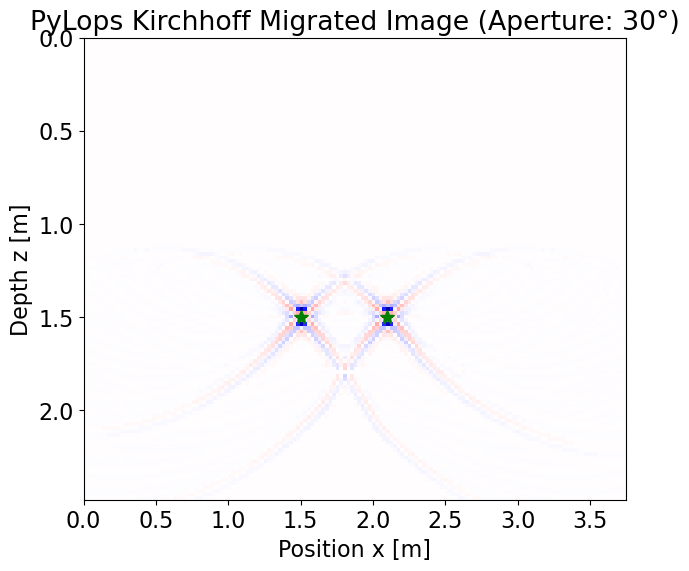

In [10]:
# Apply the Pylops Kirchhoff migration to the synthetic B-scan
# We also return the operator K_syn to use for Least Squares Migration
img_syn_pylops, K_syn = PylopsKirchoffMigration(data_synth.T, t_syn, x_syn, v_syn, z_syn, f0=1.0, angleaperture=40.0, return_op=True)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
vmax_p = np.max(np.abs(img_syn_pylops)) * 0.8
ax.imshow(img_syn_pylops, aspect='auto', extent=[x_syn[0], x_syn[-1], z_syn[-1], z_syn[0]],
              cmap='seismic', vmin=-vmax_p, vmax=vmax_p)
ax.set_title('PyLops Kirchhoff Migrated Image (Aperture: 30°)')
ax.set_xlabel('Position x [m]')
ax.set_ylabel('Depth z [m]')
for px, pz in scatterers:
    ax.plot(px, pz, 'g*', markersize=10)
plt.show()

K_syn.dims (nx,nz) = (151, 125), K_syn.shape = (120800, 18875)
Adjoint peak amplitude = 586.6043
Solving LSQR (200 iterations)...


  done in 20.7s  |  itn=200  istop=7
FISTA eps = 46.9283  (8% of adjoint peak 586.6043)
Solving FISTA (150 iterations)...
  done in 38.9s


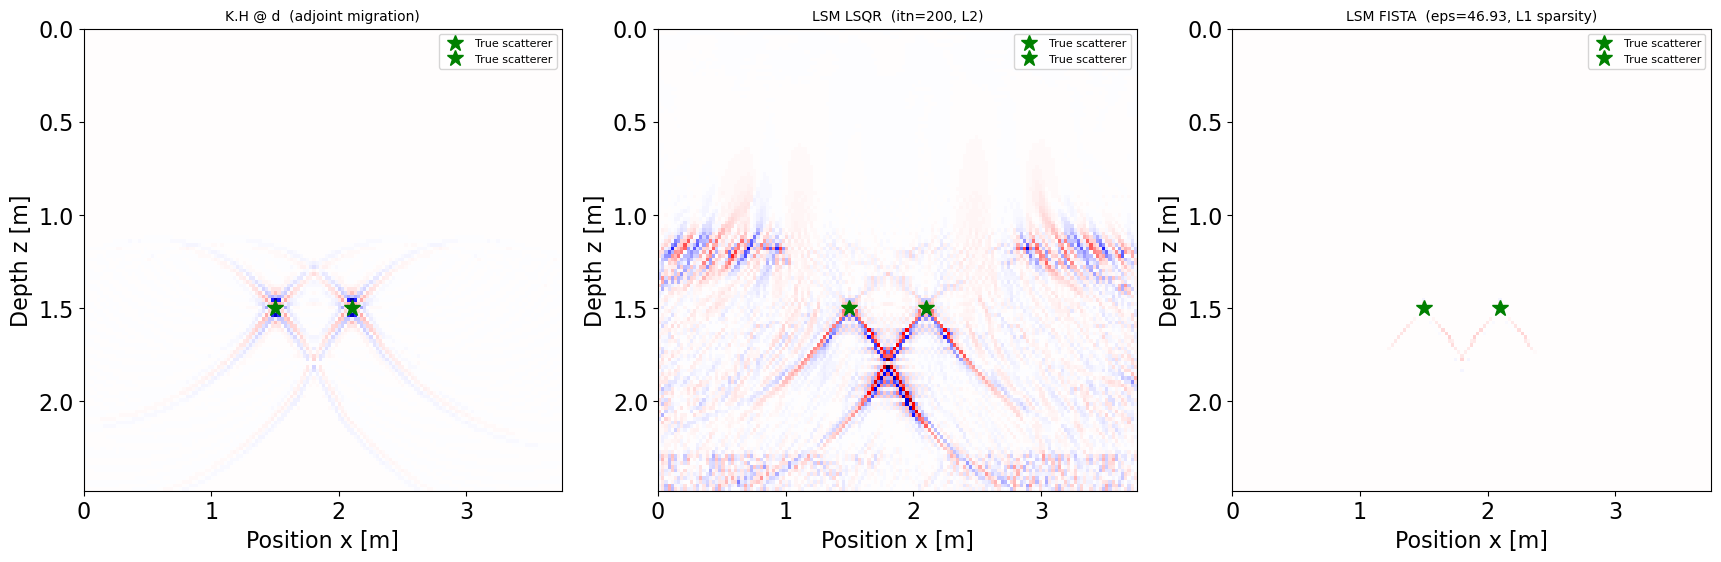

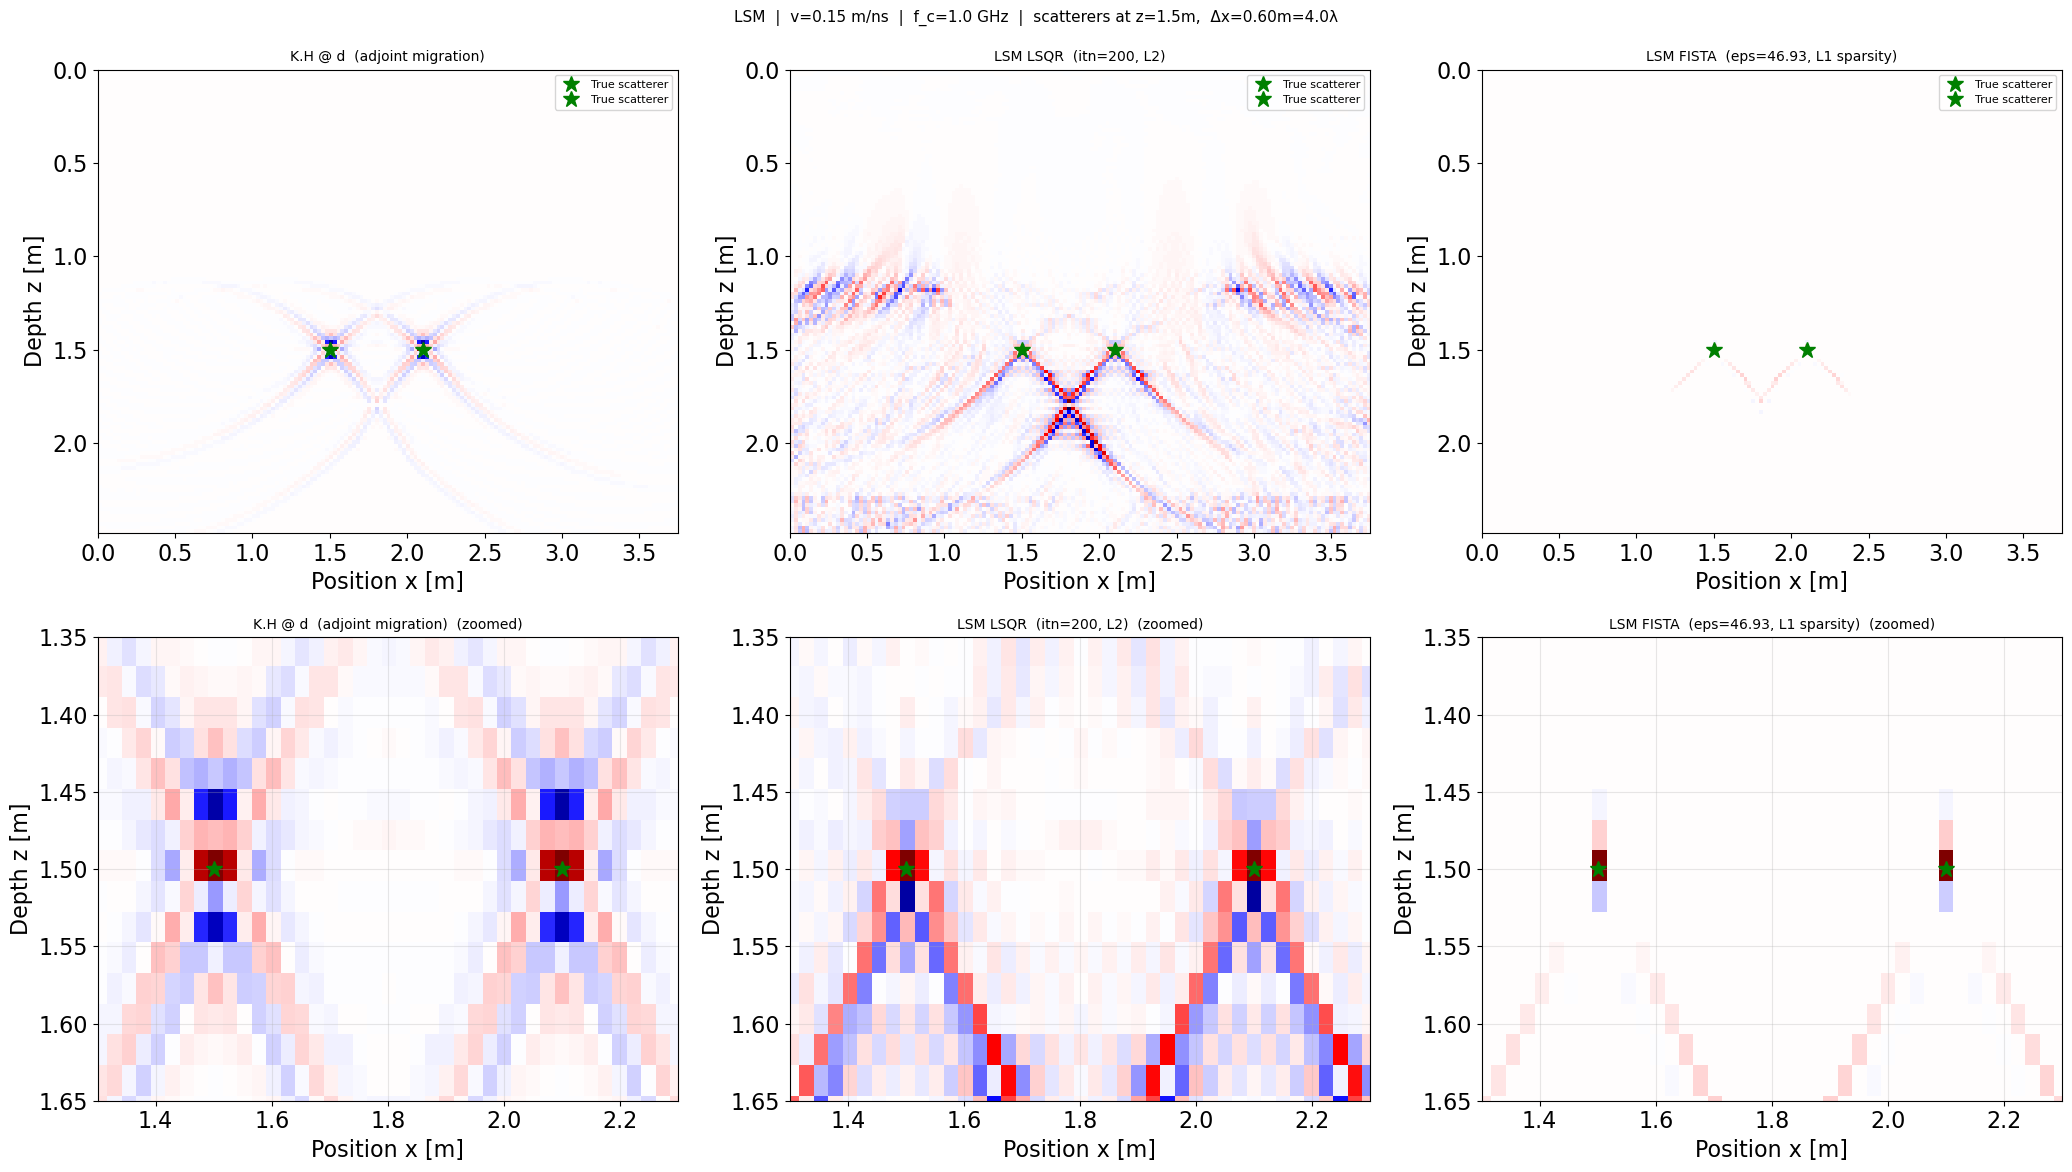

In [11]:
import pylops
import numpy as np
import time as _time
from scipy.sparse.linalg import lsqr

# z_syn must be defined here in case cell 07b48795 was run with that line commented out
z_syn = np.arange(0, 2.5, 0.02)  # depth axis [m], 125 samples

# K_syn.dims = (nx, nz) = (151, 125)  →  model vector length = 151*125 = 18875
# K_syn.dimsd = (n, nt) = (151, 800)  →  data vector length = 151*800 = 120800
print(f"K_syn.dims (nx,nz) = {K_syn.dims}, K_syn.shape = {K_syn.shape}")

# Data as flat vector in (n, nt) row-major order — matches K_syn.dimsd layout
d_flat = data_synth.T.ravel()  # data_synth is (nt, nx), .T → (nx, nt), ravel row-major

# ── Adjoint (standard Kirchhoff migration) ────────────────────────────────────
# This is the cheapest reference: m_adj = K^H @ d (one pass, no iteration)
m_adj_flat = K_syn.H @ d_flat
img_adj = m_adj_flat.reshape(len(x_syn), len(z_syn)).T  # (nz, nx)
adj_peak = np.max(np.abs(img_adj))
print(f"Adjoint peak amplitude = {adj_peak:.4f}")

# ── LSQR — least-squares migration (L2) ──────────────────────────────────────
print("Solving LSQR (200 iterations)...")
t0 = _time.perf_counter()
lsqr_result = lsqr(K_syn, d_flat, iter_lim=200)
m_lsqr, istop, itn = lsqr_result[0], lsqr_result[1], lsqr_result[2]
print(f"  done in {_time.perf_counter()-t0:.1f}s  |  itn={itn}  istop={istop}")
img_lsm = m_lsqr.reshape(len(x_syn), len(z_syn)).T  # (nz, nx)  ← KEY: reshape before .T

# ── FISTA — sparsity-promoting migration (L1) ─────────────────────────────────
# eps must be on the same scale as the adjoint image amplitude.
# Too small → no sparsity (degenerates to L2); too large → empty image.
# A good starting point: ~5–15% of the adjoint peak.
eps = adj_peak * 0.08
print(f"FISTA eps = {eps:.4f}  (8% of adjoint peak {adj_peak:.4f})")
print("Solving FISTA (150 iterations)...")
t0 = _time.perf_counter()
fista_out = pylops.optimization.sparsity.fista(
    K_syn, d_flat, eps=eps, niter=150, show=False
)
m_fista = fista_out[0]  # model is always first element regardless of PyLops version
print(f"  done in {_time.perf_counter()-t0:.1f}s")
img_lsm_sparse = m_fista.reshape(len(x_syn), len(z_syn)).T  # (nz, nx)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(21, 6))
ext = [x_syn[0], x_syn[-1], z_syn[-1], z_syn[0]]

panels = [
    (img_adj,        f'K.H @ d  (adjoint migration)'),
    (img_lsm,        f'LSM LSQR  (itn={itn}, L2)'),
    (img_lsm_sparse, f'LSM FISTA  (eps={eps:.2f}, L1 sparsity)'),
]
for ax, (img, title) in zip(axs, panels):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', extent=ext, cmap='seismic',
              vmin=-vmax, vmax=vmax, origin='upper')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Position x [m]')
    ax.set_ylabel('Depth z [m]')
    for px, pz in scatterers:
        ax.plot(px, pz, 'g*', markersize=12, label='True scatterer')
    ax.legend(fontsize=8, loc='upper right')

fig, axs = plt.subplots(2, 3, figsize=(21, 12))

# ── Row 1: Full depth range ────────────────────────────────────────────────
ext = [x_syn[0], x_syn[-1], z_syn[-1], z_syn[0]]

panels = [
    (img_adj,        f'K.H @ d  (adjoint migration)'),
    (img_lsm,        f'LSM LSQR  (itn={itn}, L2)'),
    (img_lsm_sparse, f'LSM FISTA  (eps={eps:.2f}, L1 sparsity)'),
]
for ax, (img, title) in zip(axs[0], panels):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', extent=ext, cmap='seismic',
              vmin=-vmax, vmax=vmax, origin='upper')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Position x [m]')
    ax.set_ylabel('Depth z [m]')
    for px, pz in scatterers:
        ax.plot(px, pz, 'g*', markersize=12, label='True scatterer')
    ax.legend(fontsize=8, loc='upper right')

# ── Row 2: Zoomed in on scatterers ────────────────────────────────────────
z_min, z_max = scatterers[0][1] - 0.15, scatterers[0][1] + 0.15
x_min, x_max = min(scatterers[0][0], scatterers[1][0]) - 0.2, \
               max(scatterers[0][0], scatterers[1][0]) + 0.2

ext_zoom = [x_min, x_max, z_max, z_min]

for ax, (img, title) in zip(axs[1], panels):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', extent=ext, cmap='seismic',
              vmin=-vmax, vmax=vmax, origin='upper')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(z_max, z_min)
    ax.set_title(title + '  (zoomed)', fontsize=10)
    ax.set_xlabel('Position x [m]')
    ax.set_ylabel('Depth z [m]')
    for px, pz in scatterers:
        ax.plot(px, pz, 'g*', markersize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f'LSM  |  v={v_syn} m/ns  |  f_c={fc} GHz  |  '
    f'scatterers at z={scatterers[0][1]:.1f}m,  Δx={distance:.2f}m={distance/wavelength:.1f}λ',
    fontsize=11
)
plt.tight_layout()
plt.show()


## Gazdag Phase-Shift Migration (PyLops) — Synthetic B-Scan

Uses `pylops.waveeqprocessing.PhaseShift` for iterative depth stepping.
The exploding-reflector half-velocity `v_mig = v/2` is used so that phase propagation
to depth `z` accounts for the full two-way travel time.

**Imaging condition:** after continuing the wavefield to depth `z`, the `t = 0` sample
of each trace gives the reflectivity — equivalent to summing all frequency components.

In [12]:
import time as _time

def gazdag_phaseshift_pylops(data, x, t, z, vel,
                              f_min_GHz=0.2, f_max_GHz=3.0):
    """
    Gazdag (1978) phase-shift migration for zero-offset post-stack data.

    Direct f-kx implementation — no PyLops PhaseShift black box.

      kz = sqrt( max(0, (omega/v_mig)^2 - kx^2) )
      depth loop: D *= exp(i * kz * dz),  D[evanescent] = 0  after every step

    PyLops PhaseShift clamps evanescent kz to 0 (pass-through, not kill),
    so those bins accumulate at the t=0 imaging condition over many depth
    steps and produce upside-down parabola ('smile') artefacts.
    Re-zeroing explicitly after each step prevents any accumulation.

    data  : (nt, nx)  zero-offset B-scan, time axis first
    x, t  : 1-D coordinate arrays [m, ns]
    z     : 1-D depth axis [m], uniformly spaced from 0
    vel   : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Returns image (nz, nx), peak-normalised to ±1.
    """
    nt, nx = data.shape
    dt = float(t[1] - t[0])
    dx = float(x[1] - x[0])
    v_mig = vel / 2.0   # exploding-reflector half-velocity

    # Spatial cosine taper (5 %) + 100 % symmetric zero-pad
    n_tap = max(3, int(0.05 * nx))
    pad   = nx             # nx zeros each side → nx_pad = 3 nx
    sp_tap          = np.ones(nx)
    sp_tap[:n_tap]  = 0.5 * (1 - np.cos(np.pi * np.arange(n_tap) / n_tap))
    sp_tap[-n_tap:] = sp_tap[:n_tap][::-1]
    data_padded = np.pad(data * sp_tap[None, :],
                         ((0, 0), (pad, pad)), mode='constant')  # (nt, nx_pad)
    nx_pad = nx + 2 * pad

    # 2-D FFT → (f, kx) domain
    D = np.fft.fft2(data_padded)                    # (nt, nx_pad)

    f_arr = np.fft.fftfreq(nt, dt)                  # [GHz]
    kx    = 2 * np.pi * np.fft.fftfreq(nx_pad, dx)  # [rad/m]
    omega = 2 * np.pi * f_arr                        # [rad/ns]

    # Bandpass — removes DC/near-DC and above-signal noise
    band = (np.abs(f_arr) >= f_min_GHz) & (np.abs(f_arr) <= f_max_GHz)
    D[~band, :] = 0.0

    # Dispersion + evanescent mask (computed once, applied every step)
    kz2       = (omega[:, None] / v_mig)**2 - kx[None, :]**2  # (nt, nx_pad)
    kz        = np.sqrt(np.maximum(kz2, 0.0))
    evan_mask = kz2 <= 0
    D[evan_mask] = 0.0      # zero evanescent before depth loop

    print(f'  nx={nx} → nx_pad={nx_pad}  (+{2*pad} spatial zeros)')
    print(f'  Bandpass: {band.sum()}/{nt} bins kept  '
          f'({f_min_GHz:.1f}–{f_max_GHz:.1f} GHz)')
    print(f'  Evanescent bins: {evan_mask.sum()}/{evan_mask.size}'
          f' ({100*evan_mask.mean():.1f}%)')

    # Depth loop
    image  = np.zeros((len(z), nx_pad))
    z_prev = 0.0

    for iz, zi in enumerate(z):
        dz_step = zi - z_prev
        if dz_step > 0:
            D *= np.exp(1j * kz * dz_step)
            D[evan_mask] = 0.0    # re-zero evanescent after every step
        # Imaging condition: IFFT over kx (axis 1), sum over ω (axis 0) = t=0
        image[iz] = np.real(np.fft.ifft(D, axis=1).sum(axis=0))
        z_prev = zi

    # Trim symmetric spatial padding
    image = image[:, pad:-pad]
    peak  = np.max(np.abs(image))
    return image / (peak + 1e-30)


t0_perf = _time.perf_counter()
img_syn_ps = gazdag_phaseshift_pylops(data_synth, x_syn, t_syn, z_syn, v_syn)
print(f'Gazdag phase-shift done in {_time.perf_counter() - t0_perf:.1f} s'
      f'  |  shape: {img_syn_ps.shape}')

  nx=151 → nx_pad=453  (+302 spatial zeros)
  Bandpass: 226/800 bins kept  (0.2–3.0 GHz)
  Evanescent bins: 27181/362400 (7.5%)


Gazdag phase-shift done in 2.7 s  |  shape: (125, 151)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_16444\2618609924.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='lower right')


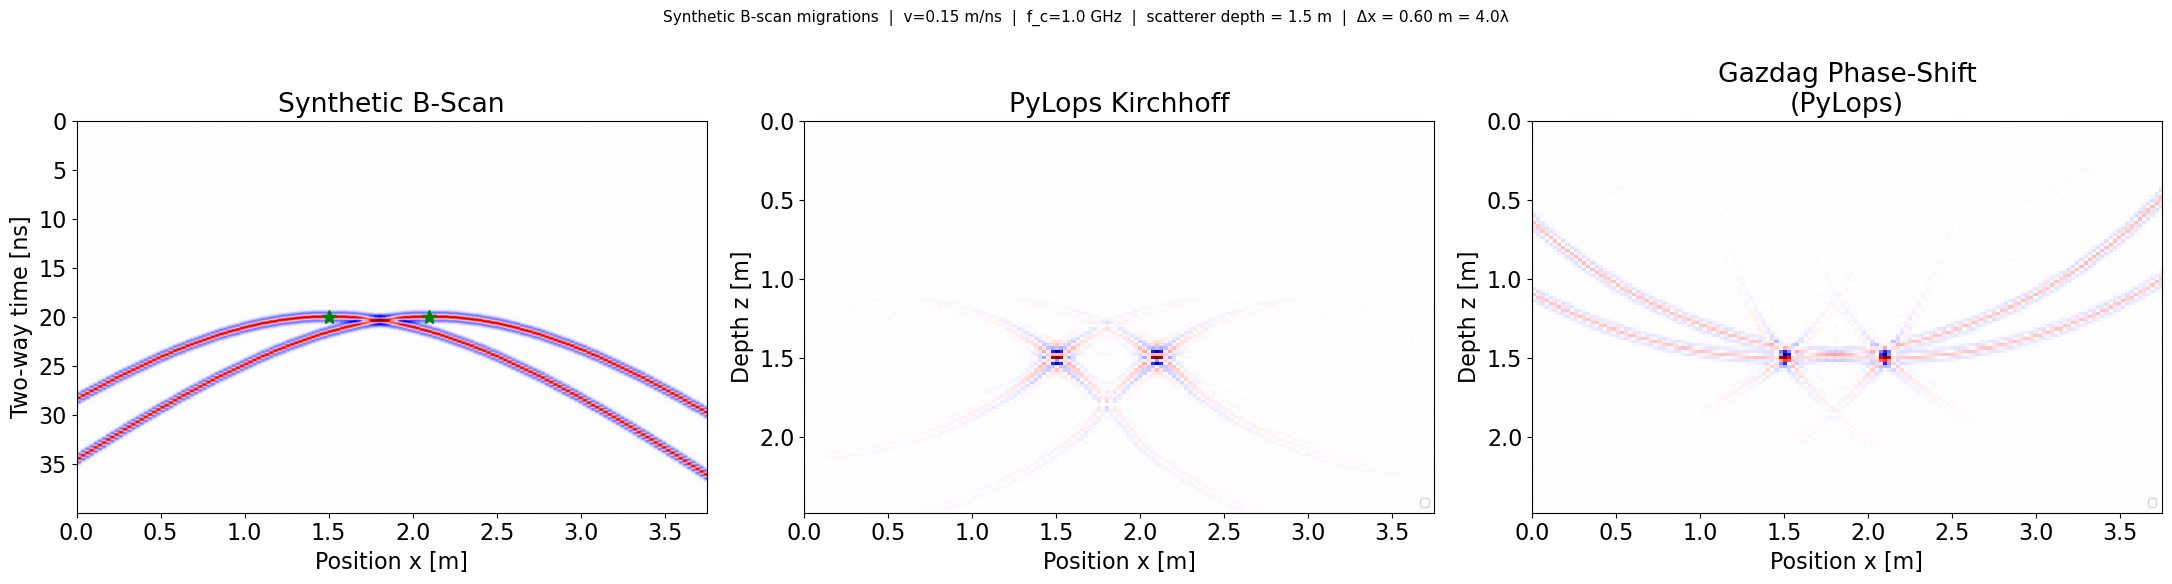

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(22, 6))

# Panel 0: raw B-scan
vmax_d = np.max(np.abs(data_synth)) * 0.8
axs[0].imshow(data_synth, aspect='auto',
              extent=[x_syn[0], x_syn[-1], t_syn[-1], t_syn[0]],
              cmap='seismic', vmin=-vmax_d, vmax=vmax_d, origin='upper')
axs[0].set_title('Synthetic B-Scan')
axs[0].set_xlabel('Position x [m]')
axs[0].set_ylabel('Two-way time [ns]')
for px, pz in scatterers:
    axs[0].plot(px, 2 * pz / v_syn, 'g*', markersize=10)

# Panels 1-3: migrated images
for ax, img, title in zip(axs[1:], [img_syn_pylops, img_syn_ps],
                          ['PyLops Kirchhoff', 'Gazdag Phase-Shift\n(PyLops)']):
    vmax_m = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto',
              extent=[x_syn[0], x_syn[-1], z_syn[-1], z_syn[0]],
              cmap='seismic', vmin=-vmax_m, vmax=vmax_m, origin='upper')
    ax.set_title(title)
    ax.set_xlabel('Position x [m]')
    ax.set_ylabel('Depth z [m]')
    # for px, pz in scatterers:
    #     ax.plot(px, pz, 'g*', markersize=10, label='True position' if px == scatterers[0][0] else '')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    f'Synthetic B-scan migrations  |  v={v_syn} m/ns  |  f_c={fc} GHz'
    f'  |  scatterer depth = {scatterers[0][1]} m  |  Δx = {distance:.2f} m = {distance/wavelength:.1f}λ',
    fontsize=11
)
plt.tight_layout()
plt.show()

In [14]:
import pylops
import time as _time

def gazdag_phaseshift_pylops(data, x, t, z, vel):
    """
    Gazdag phase-shift migration using pylops.waveeqprocessing.PhaseShift.

    data  : (nt, nx)  zero-offset B-scan, time axis first
    x, t  : 1-D coordinate arrays [m, ns]
    z     : 1-D depth axis [m], uniformly sampled from 0
    vel   : full medium velocity [m/ns]; v_mig = vel/2 used internally

    Pre-processing
    --------------
    1. Spatial cosine taper (5 % each edge) + 100 % zero-pad each side.
    2. f-kx dip filter: zero every (f, kx) bin where |kx| > |f| / v_mig.
       PyLops PhaseShift uses sqrt(max(kz², 0)) so evanescent bins (kz = 0)
       pass through unchanged at every depth step — without this filter they
       accumulate at t = 0 and create upside-down parabola ('smile') artefacts.

    Returns image (nz, nx), peak-normalised to ±1.
    """
    nt, nx = data.shape
    dt  = float(t[1] - t[0])
    dx  = float(x[1] - x[0])
    dz  = float(z[1] - z[0])
    v_mig = vel / 2.0   # exploding-reflector half-velocity

    # ── Spatial cosine taper + 100 % zero-pad on each side ───────────────
    n_xtap  = max(3, int(0.05 * nx))
    pad     = 2 * nx         # nx zeros each side → nx_pad = 3 nx
    taper   = pylops.utils.tapers.taper2d(nt, nx, n_xtap)   # (nx, nt)
    data_sp = np.pad(
        data.T * taper,             # (nx, nt)
        ((pad, pad), (0, 0)),
        mode='constant'
    )                               # (nx_pad, nt)
    nx_pad = nx + 2 * pad

    # ── f-kx dip filter: kill evanescent bins before migration ───────────
    # Forward transform: rfft in time, then full fft in space
    D_fk     = np.fft.fft(np.fft.rfft(data_sp, axis=1), axis=0)   # (nx_pad, nf)
    freq_arr = np.fft.rfftfreq(nt, dt)          # [GHz]  shape (nf,)
    kx_arr   = np.fft.fftfreq(nx_pad, dx)       # [1/m]  shape (nx_pad,)
    # Propagating condition: |kx| <= |f| / v_mig  (same relation PhaseShift uses)
    evanescent = np.abs(kx_arr[:, None]) > np.abs(freq_arr[None, :]) / v_mig
    D_fk[evanescent] = 0.0
    # Inverse transform back to (nx_pad, nt)
    data_sp = np.real(np.fft.irfft(np.fft.ifft(D_fk, axis=0), n=nt, axis=1))

    n_evan = int(evanescent.sum())
    print(f'  nx={nx} → nx_pad={nx_pad} (+{2*pad} spatial zeros, no temporal pad)')
    print(f'  Evanescent bins zeroed: {n_evan}/{evanescent.size}'
          f' ({100*n_evan/evanescent.size:.1f}%)')

    # ── PhaseShift depth loop ─────────────────────────────────────────────
    freq  = np.fft.rfftfreq(nt, dt)
    kx    = np.fft.fftshift(np.fft.fftfreq(nx_pad, dx))
    Pop   = pylops.waveeqprocessing.PhaseShift(v_mig, dz, nt, freq, kx)
    field = data_sp.T.ravel()    # (nt * nx_pad,) row-major

    image = np.zeros((len(z), nx))
    for iz in range(len(z)):
        # t = 0 imaging condition: first time sample, trim spatial padding
        image[iz] = np.real(field.reshape(nt, nx_pad)[0, pad:-pad])
        if iz < len(z) - 1:
            field = Pop * field   # downward-continue by dz

    peak = np.max(np.abs(image))
    return image / (peak + 1e-30)


t0_perf = _time.perf_counter()
img_syn_ps = gazdag_phaseshift_pylops(data_synth, x_syn, t_syn, z_syn, v_syn)
print(f'Gazdag phase-shift done in {_time.perf_counter() - t0_perf:.1f} s'
      f'  |  shape: {img_syn_ps.shape}')

  nx=151 → nx_pad=755 (+604 spatial zeros, no temporal pad)
  Evanescent bins zeroed: 23024/302755 (7.6%)


Gazdag phase-shift done in 4.3 s  |  shape: (125, 151)


---
## Resolution Study — Rayleigh Limit Analysis

Results from `run_resolution_study.py`. Six separations are compared:
**2λ → 1λ → 0.5λ → 0.25λ → 0.125λ → 0.0625λ** (λ ≈ 112.6 mm in ice at 1.5 GHz).

The Rayleigh criterion predicts the two scatterers become unresolvable below **λ/2 ≈ 56 mm**.

Three figures produced:
1. **B-scan gallery** — raw scattered field; two hyperbolas converge as Δx shrinks
2. **Migrated image gallery** — Kirchhoff (row 1) and Backpropagation (row 2) for all 6 separations
3. **1-D PSF envelope comparison** — Hilbert envelope sliced at focus depth; the –6 dB crossing shows when the two peaks merge into one

In [23]:
# Resolution Study --- Data Loading + Migration (Kirchhoff, Gazdag, Backprop, LSM)
import io, contextlib
import pylops
from scipy.signal import decimate as _scipy_decimate

wavelength_ice = v_ice / f_c_GHz   # approx 0.1126 m  (1.5 GHz in ice)

STUDY_ROOT = BASE / 'resolution_study'
BG_PATH    = BASE / 'B_Scan_Migration_data' / 'bg_bscan_merged.out'

LAMBDA_FACTORS = [2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]

def _study_dir(factor):
    label = f'{factor:g}'.replace('.', 'p')
    return STUDY_ROOT / f'study_{label}lambda'


def lsm_poststack(bscan, dt_ns, x_traces, v_medium, x_img, z_img, t0_ns,
                  f0_GHz=1.5, angleaperture=40.0, n_iter=200, eps_frac=0.08):
    """LSM via PyLops Kirchhoff operator + FISTA (L1 sparsity-promoting).

    Velocity: pass the FULL medium velocity (v_ice). The operator computes
    TWTT = trav_src + trav_rec = 2*r/vel, requiring full propagation speed.

    t0 correction: data is pre-shifted by -t0_ns to align the Ricker peak
    with t=0, matching the operator's zero-referenced travel-time model.

    Decimation: gprMax dt ~ 0.00176 ns gives a 2276-sample Ricker wavelet and
    a 2.3M-element data vector. Decimating by ~94x (target dt ~ 0.15 ns) reduces
    the data to ~90 samples with a 25-sample wavelet, making FISTA tractable.
    """
    # t0 correction: shift Ricker peak to t=0
    t0_samp = round(t0_ns / dt_ns)
    bscan_shifted = np.roll(bscan, -t0_samp, axis=1)
    bscan_shifted[:, -t0_samp:] = 0.0

    # Decimate in time to target dt ~ 0.15 ns (well below Nyquist for 3 GHz bandwidth)
    dec = max(1, int(0.15 / dt_ns))
    if dec > 1:
        bscan_d = _scipy_decimate(bscan_shifted, dec, axis=1, zero_phase=True).astype(np.float64)
        dt_d = dt_ns * dec
    else:
        bscan_d = bscan_shifted.astype(np.float64)
        dt_d = dt_ns
    time_d = np.arange(bscan_d.shape[1]) * dt_d
    print(f'    decimate {dec}x  -> dt={dt_d:.4f} ns  n_t={bscan_d.shape[1]}')

    with contextlib.redirect_stdout(io.StringIO()):
        _, K = PylopsKirchoffMigration(
            bscan_d, time_d, x_traces, v_medium, z_img,
            f0=f0_GHz, angleaperture=angleaperture, return_op=True
        )

    d_flat   = bscan_d.flatten()
    adj_peak = float(np.max(np.abs(K.H @ d_flat)))
    eps      = eps_frac * adj_peak
    print(f'    adj_peak={adj_peak:.3e}  eps={eps:.3e}  ({eps_frac} * peak)')
    m_flat   = pylops.optimization.sparsity.fista(
        K, d_flat, eps=eps, niter=n_iter, show=False
    )[0]

    img = m_flat.reshape(len(x_traces), len(z_img)).T   # (nz, n_tr)
    img_out = np.zeros((len(z_img), len(x_img)))
    for iz in range(len(z_img)):
        img_out[iz] = np.interp(x_img, x_traces, img[iz])
    peak = np.max(np.abs(img_out))
    return img_out / (peak + 1e-30)


# Load shared background (simulated without scatterers)
bscan_bg_rs, _dt_bg, _ = load_gprmax_out(BG_PATH)
print(f'Background B-scan: {bscan_bg_rs.shape}  dt={_dt_bg:.6f} ns')

rs_results = []   # list of dicts per separation

for _factor in LAMBDA_FACTORS:
    _delta = _factor * wavelength_ice
    _xs1 = round((2.0 - _delta / 2) / dx_grid) * dx_grid
    _xs2 = round((2.0 + _delta / 2) / dx_grid) * dx_grid

    _psf_path = _study_dir(_factor) / 'psf_bscan_merged.out'
    print(f'\n{_factor:7g}lambda  Dx={_delta*1e3:.2f} mm  xs1={_xs1:.4f} m  xs2={_xs2:.4f} m')

    if not _psf_path.exists():
        print(f'  WARNING: {_psf_path} not found --- skipping')
        continue

    _full, _dt, _tn = load_gprmax_out(_psf_path)
    _sc = _full - bscan_bg_rs

    _ikh  = kirchhoff_poststack(_sc, _dt, x_traces, v_mig, x_img, z_img, t0_ns)
    _igz  = gazdag_poststack(   _sc, _dt, x_traces, v_mig, x_img, z_img, t0_ns)
    _ibp  = backprop_poststack( _sc, _dt, x_traces, v_ice,  x_img, z_img, t0_ns)
    print('  LSM (decimated FISTA):')
    _ilsm = lsm_poststack(_sc, _dt, x_traces, v_ice, x_img, z_img, t0_ns)

    rs_results.append(dict(
        factor=_factor, delta_m=_delta,
        xs1=_xs1, xs2=_xs2,
        bscan_sc=_sc, dt_ns=_dt, time_ns=_tn,
        img_kh=_ikh, img_gz=_igz, img_bp=_ibp, img_lsm=_ilsm,
    ))
    print(f'  KH={np.max(np.abs(_ikh)):.3f}  GZ={np.max(np.abs(_igz)):.3f}  '
          f'BP={np.max(_ibp):.3f}  LSM={np.max(np.abs(_ilsm)):.3f}  done')

print(f'\nLoaded {len(rs_results)} separations.')


Background B-scan: (269, 8533)  dt=0.00176 ns
      2lambda  Dx=225.22 mm  xs1=1.8874 m  xs2=2.1125 m
  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)


  LSM: operator + adjoint peak + FISTA (100 iter)...
  KH=1.000  GZ=1.000  BP=1.000  LSM=1.000  done
      1lambda  Dx=112.61 mm  xs1=1.9440 m  xs2=2.0566 m
  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)
  LSM: operator + adjoint peak + FISTA (100 iter)...
  KH=1.000  GZ=1.000  BP=1.000  LSM=1.000  done
    0.5lambda  Dx=56.30 mm  xs1=1.9716 m  xs2=2.0282 m
  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)
  LSM: operator + adjoint peak + FISTA (100 iter)...
  KH=1.000  GZ=1.000  BP=1.000  LSM=1.000  done
   0.25lambda  Dx=28.15 mm  xs1=1.9857 m  xs2=2.0141 m
  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)
  LSM: operator + adjoint peak + FISTA (100 iter)...
  KH=1.000  GZ=1.000  BP=1.000  LSM=1.000  done
  0.125lambda  Dx=14.08 mm  xs1=1.9932 m  xs2=2.0074 m
  Bandpass: 82 of 8533 freq bins kept (0.3-3.0 GHz)
  LSM: operator + adjoint peak + FISTA (100 iter)...
  KH=1.000  GZ=1.000  BP=1.000  LSM=1.000  done
 0.0625lambda  Dx=7.04 mm  xs1=1.9962 m  xs2=2.0036 m
  Bandpass: 

factor=2.0lam  dt=0.001758 ns  t0_samp=542  dec=85x
Dx=225.2 mm  xs1=1.8874  xs2=2.1125
Decimated: n_t=101  dt=0.1494 ns  data shape (269, 101)
Adjoint (no decim, v_ice, t0)...
Adjoint (decimated, v_ice, t0)...
adj_peak (decimated) = 3.8908e+01
FISTA A  eps_frac=0.04...
  eps=1.556e+00  (0.04 * 3.891e+01)
FISTA B  eps_frac=0.08...
  eps=3.113e+00  (0.08 * 3.891e+01)


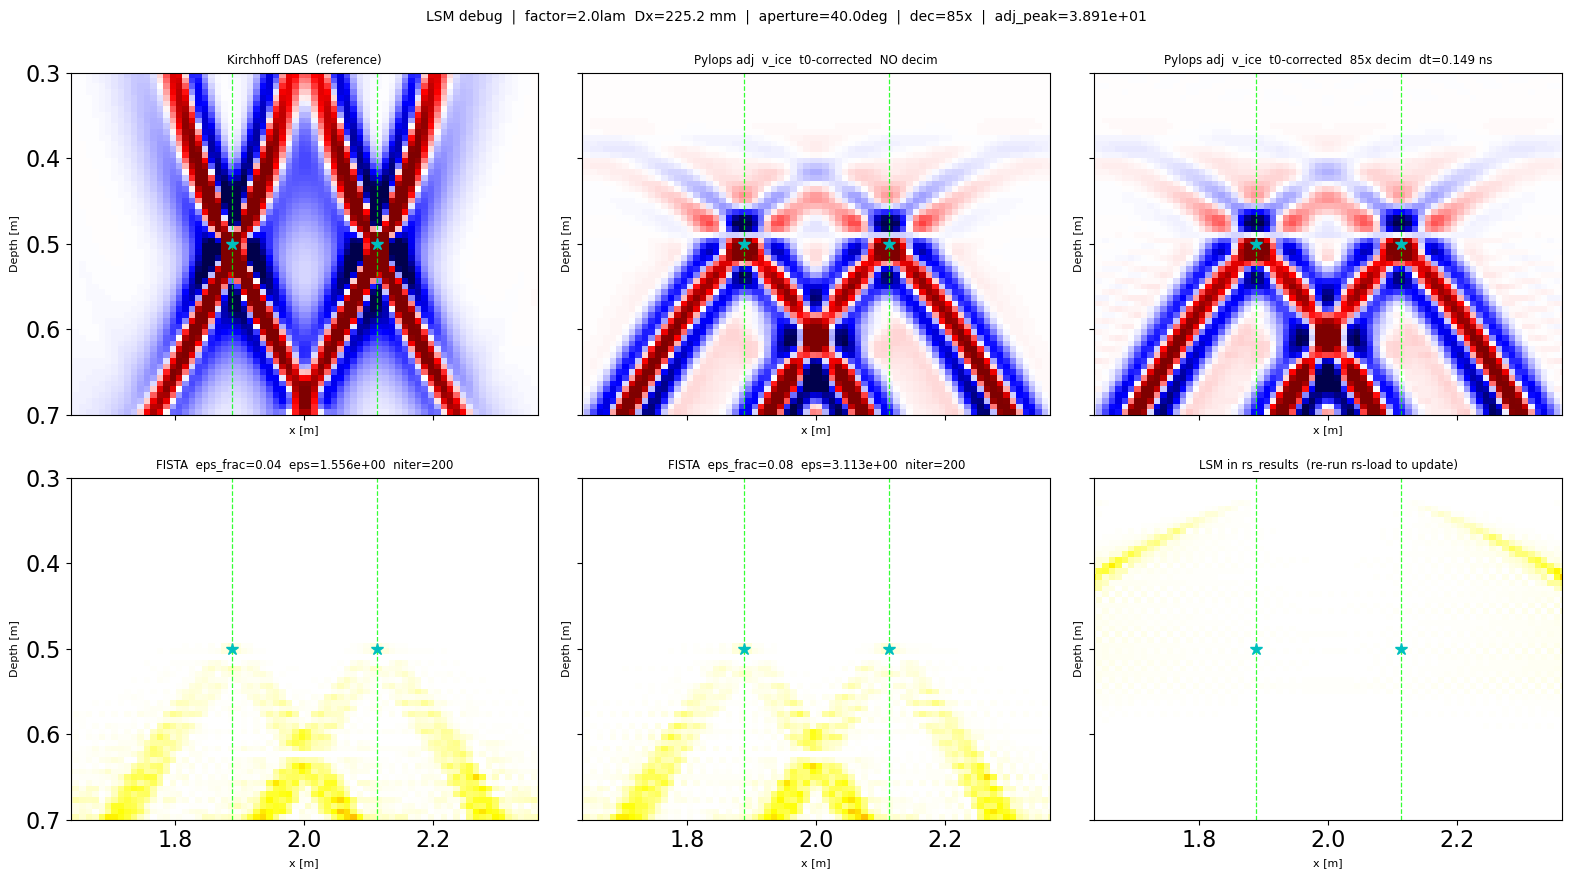

In [45]:
# ── LSM Debug Cell ─── tune settings before running full resolution study ──────────────
# Row 0 (seismic): adjoint alignment
#   [0,0] Kirchhoff DAS  (reference)
#   [0,1] Pylops adj  v_ice + t0  NO decimation  (polarity/sidelobe issues expected)
#   [0,2] Pylops adj  v_ice + t0  WITH 94x decimation  (should match Kirchhoff)
# Row 1 (hot_r): FISTA with decimated operator at two eps values
# ─────────────────────────────────────────────────────────────────────────────────────────
TEST_FACTOR  = 2.0
ANGLE_AP     = 40.0
EPS_FRAC_A   = 0.04
EPS_FRAC_B   = 0.08
N_ITER       = 200
# ─────────────────────────────────────────────────────────────────────────────────────────

import pylops, io, contextlib
from scipy.signal import decimate as _scipy_decimate

_tr = next((r for r in rs_results if r['factor'] == TEST_FACTOR), rs_results[0])
_sc, _dt = _tr['bscan_sc'], _tr['dt_ns']
_xs1, _xs2 = _tr['xs1'], _tr['xs2']
_t0samp = round(t0_ns / _dt)
_dec = max(1, int(0.15 / _dt))
print(f"factor={_tr['factor']}lam  dt={_dt:.6f} ns  t0_samp={_t0samp}  dec={_dec}x")
print(f"Dx={_tr['delta_m']*1e3:.1f} mm  xs1={_xs1:.4f}  xs2={_xs2:.4f}")

_time_ns = np.arange(_sc.shape[1]) * _dt

# t0-corrected data
_sc_shifted = np.roll(_sc, -_t0samp, axis=1)
_sc_shifted[:, -_t0samp:] = 0.0

# Decimated data
_sc_dec = _scipy_decimate(_sc_shifted, _dec, axis=1, zero_phase=True).astype(np.float64)
_dt_dec = _dt * _dec
_time_dec = np.arange(_sc_dec.shape[1]) * _dt_dec
print(f'Decimated: n_t={_sc_dec.shape[1]}  dt={_dt_dec:.4f} ns  '
      f'data shape {_sc_dec.shape}')

def _build_adj(data, time, vel):
    with contextlib.redirect_stdout(io.StringIO()):
        _, K = PylopsKirchoffMigration(
            data, time, x_traces, vel, z_img,
            f0=f_c_GHz, angleaperture=ANGLE_AP, return_op=True
        )
    d_flat   = data.flatten()
    adj_flat = K.H @ d_flat
    adj_peak = float(np.max(np.abs(adj_flat)))
    img_raw  = adj_flat.reshape(len(x_traces), len(z_img)).T
    img = np.zeros((len(z_img), len(x_img)))
    for iz in range(len(z_img)):
        img[iz] = np.interp(x_img, x_traces, img_raw[iz])
    return img, K, d_flat, adj_peak

print('Adjoint (no decim, v_ice, t0)...')
_img_adj_nodec, _, _, _ = _build_adj(_sc_shifted, _time_ns, v_ice)
print('Adjoint (decimated, v_ice, t0)...')
_img_adj_dec, _K_dec, _d_dec, _adj_peak = _build_adj(_sc_dec, _time_dec, v_ice)
print(f'adj_peak (decimated) = {_adj_peak:.4e}')

def _fista(K, d, eps_frac, adj_peak, n_iter):
    eps = eps_frac * adj_peak
    print(f'  eps={eps:.3e}  ({eps_frac} * {adj_peak:.3e})')
    m   = pylops.optimization.sparsity.fista(K, d, eps=eps, niter=n_iter, show=False)[0]
    img_raw = m.reshape(len(x_traces), len(z_img)).T
    img = np.zeros((len(z_img), len(x_img)))
    for iz in range(len(z_img)):
        img[iz] = np.interp(x_img, x_traces, img_raw[iz])
    return img, eps

print(f'FISTA A  eps_frac={EPS_FRAC_A}...')
_img_fa, _eps_a = _fista(_K_dec, _d_dec, EPS_FRAC_A, _adj_peak, N_ITER)
print(f'FISTA B  eps_frac={EPS_FRAC_B}...')
_img_fb, _eps_b = _fista(_K_dec, _d_dec, EPS_FRAC_B, _adj_peak, N_ITER)

# ── Plot ──────────────────────────────────────────────────────────────────────
_ext  = [x_img[0], x_img[-1], z_img[-1], z_img[0]]
_xlim = (min(_xs1, _xs2) - 0.25, max(_xs1, _xs2) + 0.25)
_ylim = (z_scat + 0.20, z_scat - 0.20)

def _mark(ax):
    ax.axvline(_xs1, color='lime', ls='--', lw=0.9, alpha=0.8)
    ax.axvline(_xs2, color='lime', ls='--', lw=0.9, alpha=0.8)
    ax.plot(_xs1, z_scat, 'c*', ms=9, zorder=5)
    ax.plot(_xs2, z_scat, 'c*', ms=9, zorder=5)
    ax.set_xlim(*_xlim)
    ax.set_ylim(*_ylim)
    ax.set_xlabel('x [m]', fontsize=8)
    ax.set_ylabel('Depth [m]', fontsize=8)

fig, axs = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

# Row 0: adjoint comparison (seismic)
for ax, img, title in [
    (axs[0,0], _tr['img_kh'],
     'Kirchhoff DAS  (reference)'),
    (axs[0,1], _img_adj_nodec / (np.max(np.abs(_img_adj_nodec)) + 1e-30),
     f'Pylops adj  v_ice  t0-corrected  NO decim'),
    (axs[0,2], _img_adj_dec / (np.max(np.abs(_img_adj_dec)) + 1e-30),
     f'Pylops adj  v_ice  t0-corrected  {_dec}x decim  dt={_dt_dec:.3f} ns'),
]:
    _p = np.percentile(np.abs(img), 99)
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-_p, vmax=_p,
              extent=_ext, origin='upper')
    ax.set_title(title, fontsize=8.5)
    _mark(ax)

# Row 1: FISTA envelope (decimated operator)
for ax, img, title in [
    (axs[1,0], _img_fa,
     f'FISTA  eps_frac={EPS_FRAC_A}  eps={_eps_a:.3e}  niter={N_ITER}'),
    (axs[1,1], _img_fb,
     f'FISTA  eps_frac={EPS_FRAC_B}  eps={_eps_b:.3e}  niter={N_ITER}'),
    (axs[1,2], _tr['img_lsm'],
     'LSM in rs_results  (re-run rs-load to update)'),
]:
    _env = hilbert_env(img)
    ax.imshow(_env, aspect='auto', cmap='hot_r', vmin=0, vmax=1,
              extent=_ext, origin='upper')
    ax.set_title(title, fontsize=8.5)
    _mark(ax)

fig.suptitle(
    f'LSM debug  |  factor={_tr["factor"]}lam  Dx={_tr["delta_m"]*1e3:.1f} mm  |  '
    f'aperture={ANGLE_AP}deg  |  dec={_dec}x  |  adj_peak={_adj_peak:.3e}',
    fontsize=10)
plt.tight_layout()
plt.show()


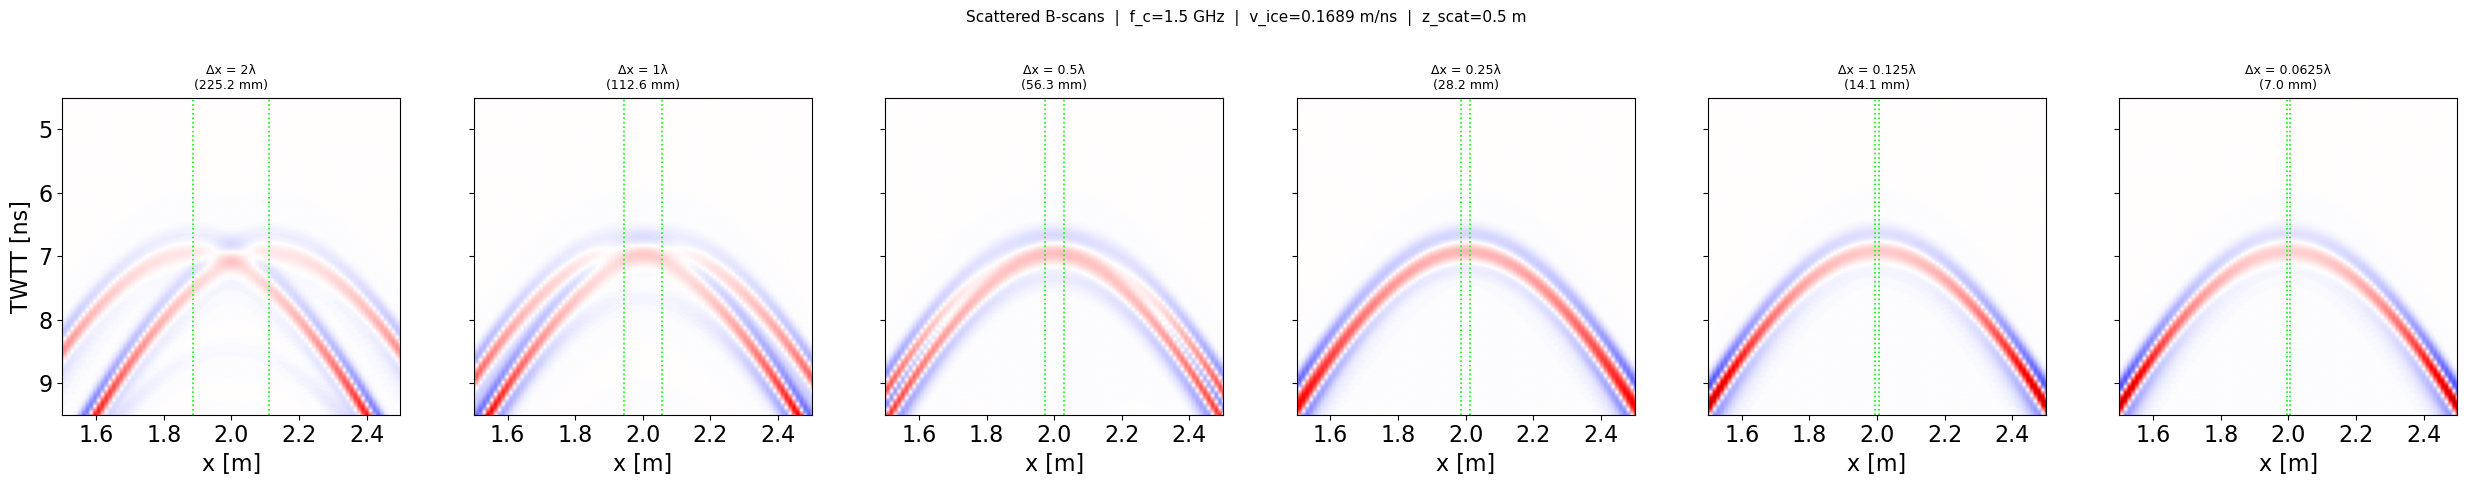

Saved: gallery_bscans.png


In [24]:
# Figure 1 — B-scan gallery (1 row × N cols, scattered field zoomed)

_n = len(rs_results)
_fig1, _axes1 = plt.subplots(1, _n, figsize=(4.2 * _n, 5), sharey=True)
if _n == 1:
    _axes1 = [_axes1]

for _ax, r in zip(_axes1, rs_results):
    _p = np.percentile(np.abs(r['bscan_sc']), 99)
    _ax.imshow(r['bscan_sc'].T, aspect='auto', cmap='seismic',
               vmin=-_p, vmax=_p,
               extent=[x_traces[0], x_traces[-1], r['time_ns'][-1], 0],
               origin='upper')
    _ax.set_xlim(1.5, 2.5)
    _ax.set_ylim(9.5, 4.5)
    _ax.axvline(r['xs1'], color='lime', ls=':', lw=1.2)
    _ax.axvline(r['xs2'], color='lime', ls=':', lw=1.2)
    _ax.set_title(f'Δx = {r["factor"]:g}λ\n({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
    _ax.set_xlabel('x [m]')

_axes1[0].set_ylabel('TWTT [ns]')
_fig1.suptitle(
    f'Scattered B-scans  |  f_c={f_c_GHz} GHz  |  v_ice={v_ice:.4f} m/ns  |  z_scat={z_scat} m',
    fontsize=11
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gallery_bscans.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gallery_bscans.png')


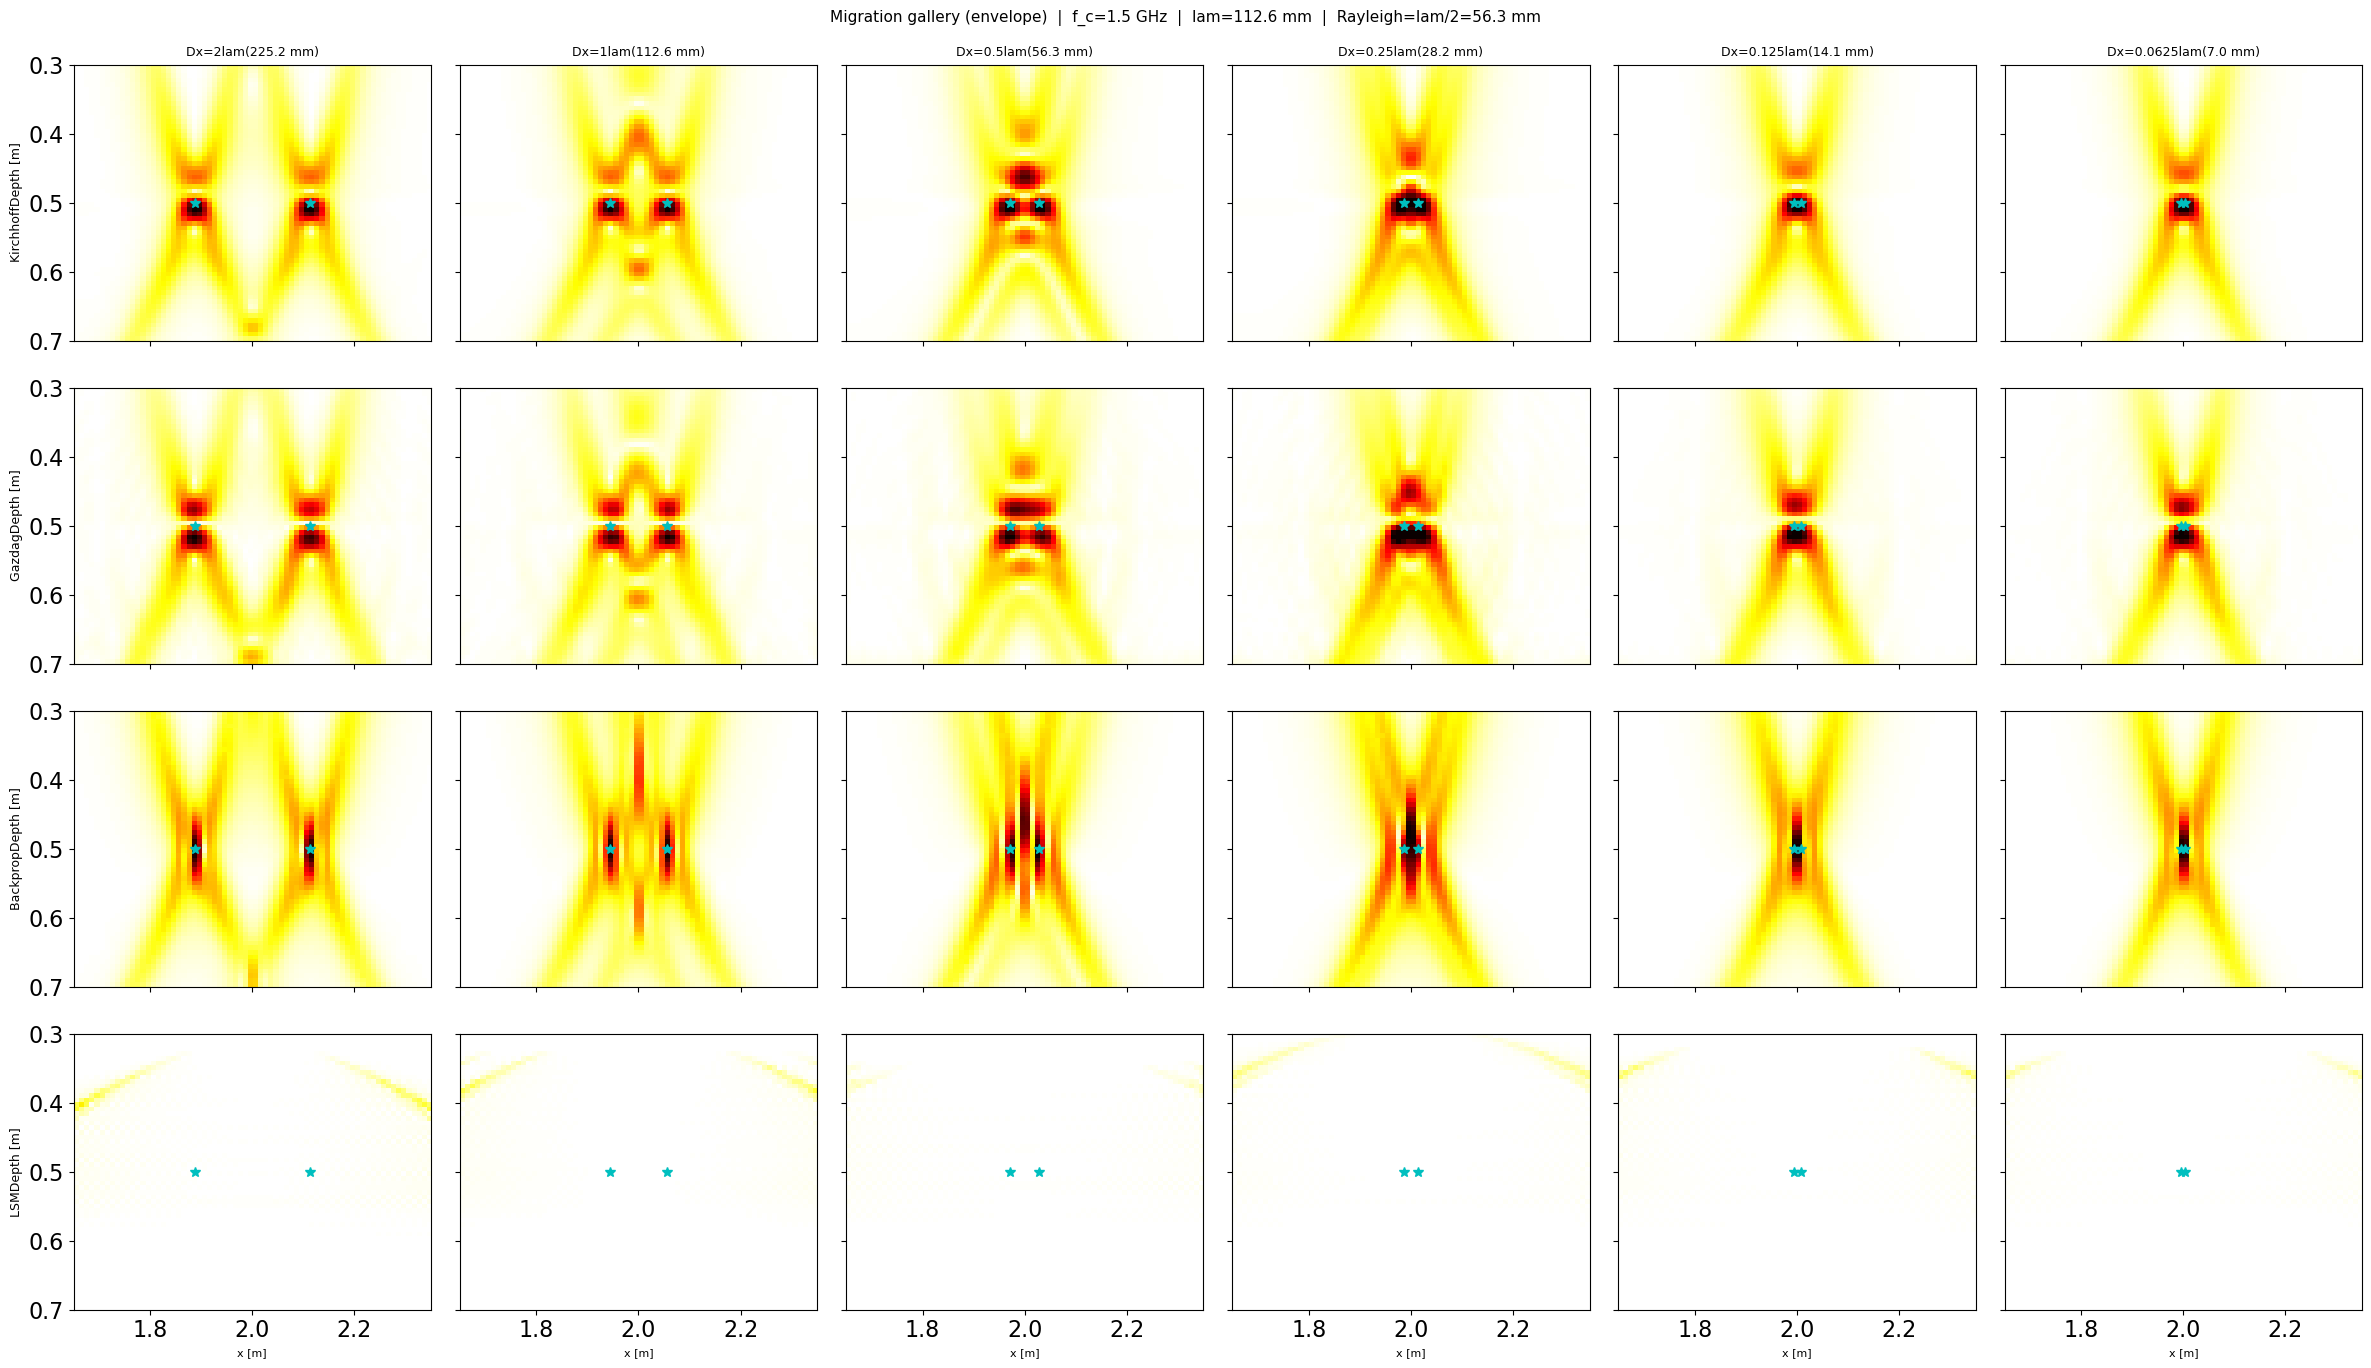

Saved: gallery_migrations.png


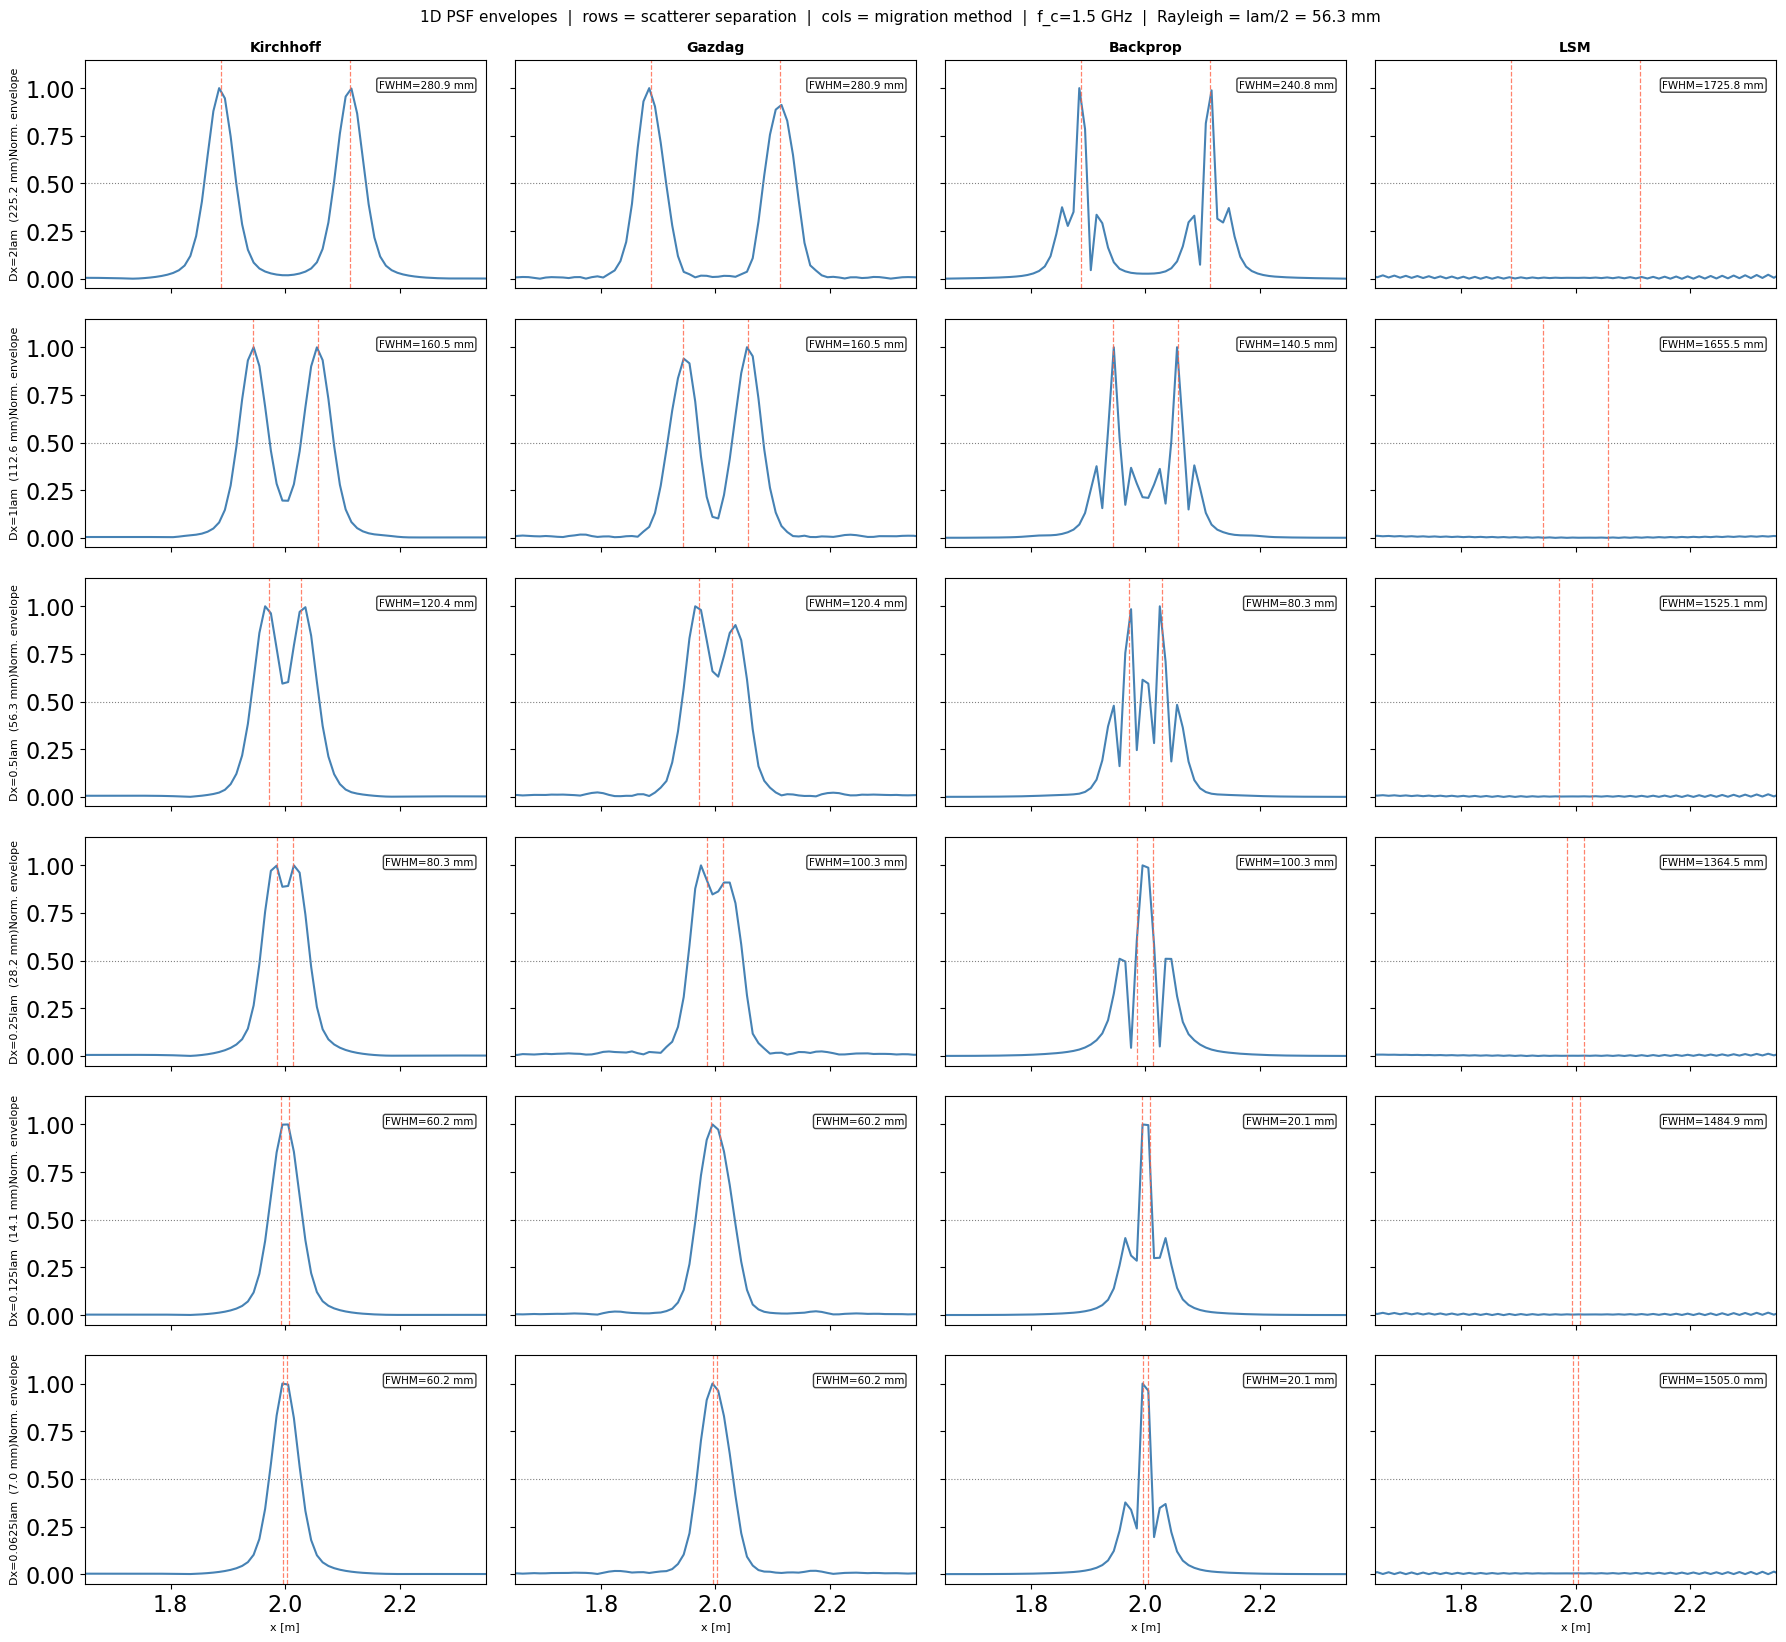

Saved: psf_envelopes_1d.png


In [25]:
# Figure 2 -- Migration gallery  (4 methods x N separations, Hilbert envelope)
_n = len(rs_results)
_methods = [
    ('img_kh',  'Kirchhoff'),
    ('img_gz',  'Gazdag'),
    ('img_bp',  'Backprop'),
    ('img_lsm', 'LSM'),
]
_n_methods = len(_methods)

_fig2, _ax2 = plt.subplots(_n_methods, _n,
                            figsize=(4.0 * _n, 3.5 * _n_methods),
                            sharex=True, sharey=True)

for _row, (_key, _lbl) in enumerate(_methods):
    for _col, r in enumerate(rs_results):
        _ax = _ax2[_row, _col]
        _img = r[_key]
        _env = _img / (np.max(_img) + 1e-30) if _key == 'img_bp' else hilbert_env(_img)
        _ax.imshow(_env, aspect='auto', cmap='hot_r', vmin=0, vmax=1,
                   extent=[x_img[0], x_img[-1], z_img[-1], z_img[0]], origin='upper')
        _ax.set_xlim(1.65, 2.35)
        _ax.set_ylim(0.70, 0.30)
        _ax.plot(r['xs1'], z_scat, 'c*', ms=7, zorder=5)
        _ax.plot(r['xs2'], z_scat, 'c*', ms=7, zorder=5)
        if _col == 0:
            _ax.set_ylabel(f'{_lbl}Depth [m]', fontsize=9)
        if _row == 0:
            _ax.set_title(f'Dx={r["factor"]:g}lam({r["delta_m"]*1e3:.1f} mm)', fontsize=9)
        if _row == _n_methods - 1:
            _ax.set_xlabel('x [m]', fontsize=8)

_fig2.suptitle(
    f'Migration gallery (envelope)  |  f_c={f_c_GHz} GHz  |  '
    f'lam={wavelength_ice*1e3:.1f} mm  |  Rayleigh=lam/2={wavelength_ice/2*1e3:.1f} mm',
    fontsize=11)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gallery_migrations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gallery_migrations.png')


# Figure 3 -- 1D PSF envelope grid  (rows = scatterer separation, cols = method)
# Each subplot shows the normalised PSF envelope at the peak depth for one
# (method, separation) combination -- clean comparison without overloading one axes.
_methods_psf = [
    ('img_kh',  'Kirchhoff'),
    ('img_gz',  'Gazdag'),
    ('img_bp',  'Backprop'),
    ('img_lsm', 'LSM'),
]
_n_rows = len(rs_results)
_n_cols = len(_methods_psf)

_fig3, _ax3 = plt.subplots(_n_rows, _n_cols,
                            figsize=(4.5 * _n_cols, 2.8 * _n_rows),
                            sharex=True, sharey=True)

for _row, r in enumerate(rs_results):
    for _col, (_key, _lbl) in enumerate(_methods_psf):
        _ax = _ax3[_row, _col]
        _img = r[_key]
        _e2d = _img / (np.max(_img) + 1e-30) if _key == 'img_bp' else hilbert_env(_img)
        _iz  = find_peak_depth(_e2d, z_img, z_scat)
        _e1d = _e2d[_iz] / (np.max(_e2d[_iz]) + 1e-30)
        _fw  = fwhm(x_img, _e1d)
        _fw_str = f'{_fw*1e3:.1f} mm' if not np.isnan(_fw) else 'N/A'

        _ax.plot(x_img, _e1d, color='steelblue', lw=1.5)
        _ax.axvline(r['xs1'], color='tomato', ls='--', lw=0.9, alpha=0.8)
        _ax.axvline(r['xs2'], color='tomato', ls='--', lw=0.9, alpha=0.8)
        _ax.axhline(0.5, color='gray', ls=':', lw=0.8)
        _ax.set_xlim(1.65, 2.35)
        _ax.set_ylim(-0.05, 1.15)
        _ax.text(0.97, 0.91, f'FWHM={_fw_str}', transform=_ax.transAxes,
                 fontsize=7.5, ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75))

        if _row == 0:
            _ax.set_title(_lbl, fontsize=10, fontweight='bold')
        if _col == 0:
            _ax.set_ylabel(f'Dx={r["factor"]:g}lam  ({r["delta_m"]*1e3:.1f} mm)Norm. envelope',
                fontsize=8)
        if _row == _n_rows - 1:
            _ax.set_xlabel('x [m]', fontsize=8)

_fig3.suptitle(
    f'1D PSF envelopes  |  rows = scatterer separation  |  cols = migration method  |  '
    f'f_c={f_c_GHz} GHz  |  Rayleigh = lam/2 = {wavelength_ice/2*1e3:.1f} mm',
    fontsize=11)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'psf_envelopes_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: psf_envelopes_1d.png')
